In [ ]:
### With full data

In [ ]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import LabelEncoder, MinMaxScaler
from sklearn.model_selection import train_test_split
from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import classification_report, confusion_matrix, balanced_accuracy_score, cohen_kappa_score
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import cross_val_predict
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout, Masking, BatchNormalization
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from tensorflow.keras.regularizers import l2
from tensorflow.keras.utils import to_categorical
from sklearn.model_selection import StratifiedKFold


# Load the data - removed duplicate load
data = pd.read_csv('sledataempl.csv', parse_dates=['ASSDT'], low_memory=False)
origdata =  pd.read_csv('sledataempl.csv', parse_dates=['ASSDT'], low_memory=False)
# Sort by patient and assessment date
data = data.sort_values(['PTNO', 'ASSDT'])

# Calculate time differences
data['time_since_first'] = data.groupby('PTNO')['ASSDT'].transform(
    lambda x: (x - x.min()).dt.days
)
data['time_since_last'] = data.groupby('PTNO')['ASSDT'].transform(
    lambda x: x.diff().dt.days.fillna(0)
)

# Convert categorical EMPf to numerical
emp_mapping = {v: k for k, v in enumerate(data['EMPf'].unique())}
data['EMP_numeric'] = data['EMPf'].map(emp_mapping)

# Encode the target (end_state)
label_encoder = LabelEncoder()
data['end_state_encoded'] = label_encoder.fit_transform(data['end_state'])

# Encode steroid categories (Low/Medium/High)
steroid_mapping = {'Low': 0, 'Medium': 1, 'High': 2}
data['STEROID_CAT_numeric'] = data['STEROID_CAT'].map(steroid_mapping)

# Features to use - including SDI (score_n) along with flares and steroid categories
features = ['severe_flare', 'mild_flare', 
            'STEROID_CAT_numeric', 'ISDOSE', 'INCEPT', 'AMDOSE', 
            'age_at_record', 'AGE_DX', 'time_since_last', 'time_since_first', 
            'visit_num', 'score_n', "AMS",  'SLED1_I', 'SLED2_I', 'SLED3_I', 'SLED4_I', 'SLED5_I', 'SLED6_I',
            'SLED7_I', 'SLED8_I', 'SLED9_I', 'SLED10_I', 'SLED11_I', 'SLED12_I', 'SLED13_I', 'SLED14_I', 'SLED15_I',
            'SLED16_I', 'SLED17_I', 'SLED18_I', 'SLED19_I', 'SLED20_I', 'SLED21_I', 'SLED22_I', 'SLED23_I', 'SLED24_I',
            'SLEDAI2_I', 'ACATARACT', 'RETOPT', 'COGNIMP', 'SEIZURX6', 'CERVASAC', 'CPNEUR', 'TRANMYEL',
            'GFR50', 'PROT24', 'ENDRENAL', 'PULMHYP', 'PULMFIBR', 'SHRINKL', 'PLEURFIBR', 'PULMINF', 'ANGBYP',
            'MYOCARINF', 'CARDMYOP', 'VALVULAR', 'PERICARD6','CLAUDIC', 'MINORTL', 'SIGNIFTL', 'VENTHROMB',
            'INFRESEC', 'MESENINS', 'PERITONIT', 'STRICTURE', 'PANCREAT', 'ATROPHY', 'DEARTHRIT', 'OSTEOPOR',
            'AVASCNEC', 'OSTEOMYEL', 'RUPTEND','ALOPECIA','EXTSCARR',
             'SKULCER','GONADALF','DIABETES','MALIGNAN']  # Added score_n (SDI)

# Add total flares feature
data['total_flare'] = data['severe_flare'] + data['mild_flare']

# Add interaction terms between important features
data['steroid_flare_interaction'] = data['STEROID_CAT_numeric'] * data['total_flare']
data['sdi_flare_interaction'] = data['score_n'] * data['total_flare']

# Add temporal features

# Correct SDI change rate calculation - using time_since_last instead of index
data['sdi_change_rate'] = data.groupby('PTNO', group_keys=False).apply(
    lambda x: x['score_n'].diff().fillna(0) / (x['time_since_last']/30 + 1e-6)  # Small constant to avoid division by zero
)

# Update features list
features += ['total_flares', 'steroid_flare_interaction', 'sdi_flare_interaction', 'sdi_change_rate']

# Identify categorical columns (non-numeric)
categorical_cols = data[features].select_dtypes(include=['object', 'category']).columns

# Label encode categorical columns
for col in categorical_cols:
    le = LabelEncoder()
    data[col] = le.fit_transform(data[col].astype(str))

# Fill NA values - for flares and SDI we'll assume 0 if missing
flare_cols = ['severe_flare', 'mild_flare']
data[flare_cols] = data[flare_cols].fillna(0)
data['score_n'] = data['score_n'].fillna(0)  # SDI
data[features] = data[features].fillna(0)

# Normalize features
scaler = MinMaxScaler()
data[features] = scaler.fit_transform(data[features])

# Create sequences for each patient
def create_sequences(data, features, max_seq_length=None):
    patients = data['PTNO'].unique()
    num_features = len(features)
    
    if not max_seq_length:
        max_seq_length = data.groupby('PTNO').size().max()
    
    X = np.zeros((len(patients), max_seq_length, num_features))
    y = np.zeros(len(patients))
    seq_lengths = np.zeros(len(patients))
    
    for i, patient in enumerate(patients):
        patient_data = data[data['PTNO'] == patient].sort_values('ASSDT')
        seq_len = len(patient_data)
        seq_lengths[i] = seq_len
        
        # Fill the sequence data
        X[i, :seq_len, :] = patient_data[features].values
        
        # Get the end_state label (last record)
        y[i] = patient_data['end_state_encoded'].iloc[-1]
    
    return X, to_categorical(y), seq_lengths

# Create sequences
# [Previous data loading and preprocessing code remains the same until sequence creation]

# Create sequences
X, y, seq_lengths = create_sequences(data, features)

# Convert y from one-hot encoded to labels for stratified k-fold
y_labels = np.argmax(y, axis=1) if len(y.shape) > 1 else y  # Handle both one-hot and label encoded

# Initialize cross-validation
n_splits = 5
skf = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=42)

# Store results
cv_results = {
    'val_accuracy': [],
    'val_loss': [],
    'test_preds': [],
    'models': []
}

# Create a test set that will be used for final evaluation
X_train_all, X_test, y_train_all, y_test, seq_train_all, seq_test = train_test_split(
    X, y, seq_lengths, test_size=0.2, random_state=42, stratify=y_labels)

# Cross-validation loop (on the training data only)
for fold, (train_idx, val_idx) in enumerate(skf.split(X_train_all, np.argmax(y_train_all, axis=1))):
    print(f"\nTraining fold {fold + 1}/{n_splits}")
    
    # Split data
    X_train, X_val = X_train_all[train_idx], X_train_all[val_idx]
    y_train, y_val = y_train_all[train_idx], y_train_all[val_idx]
    
    # Calculate class weights
    classes = np.unique(np.argmax(y_train, axis=1))
    class_weights = compute_class_weight('balanced', classes=classes, y=np.argmax(y_train, axis=1))
    class_weight_dict = dict(enumerate(class_weights))
    
    # Build model
    model = Sequential([
        Masking(mask_value=0., input_shape=(None, len(features))),
        LSTM(128, return_sequences=True, kernel_regularizer=l2(0.01)),
        BatchNormalization(),
        Dropout(0.3),
        LSTM(64, kernel_regularizer=l2(0.01)),
        BatchNormalization(),
        Dropout(0.3),
        Dense(32, activation='relu', kernel_regularizer=l2(0.01)),
        Dense(y.shape[1], activation='softmax')
    ])
    
    optimizer = Adam(learning_rate=0.001)
    model.compile(optimizer=optimizer,
                 loss='categorical_crossentropy',
                 metrics=['accuracy'])
    
    callbacks = [
        EarlyStopping(monitor='val_loss', patience=15, restore_best_weights=True),
        ReduceLROnPlateau(monitor='val_loss', factor=0.2, patience=5, min_lr=1e-6)
    ]
    
    # Train model
    history = model.fit(
        X_train,
        y_train,
        batch_size=32,
        epochs=100,
        validation_data=(X_val, y_val),
        callbacks=callbacks,
        class_weight=class_weight_dict,
        verbose=1
    )
    
    # Store results
    val_loss, val_acc = model.evaluate(X_val, y_val, verbose=0)
    cv_results['val_accuracy'].append(val_acc)
    cv_results['val_loss'].append(val_loss)
    cv_results['models'].append(model)
    
    print(f"Fold {fold + 1} - Val Accuracy: {val_acc:.4f}, Val Loss: {val_loss:.4f}")

# Print cross-validation results
print("\nCross-Validation Results:")
print(f"Mean Val Accuracy: {np.mean(cv_results['val_accuracy']):.4f} (±{np.std(cv_results['val_accuracy']):.4f})")
print(f"Mean Val Loss: {np.mean(cv_results['val_loss']):.4f} (±{np.std(cv_results['val_loss']):.4f})")

# Ensemble predictions from all folds on test set
test_preds = np.zeros((len(X_test), y.shape[1]))
for model in cv_results['models']:
    test_preds += model.predict(X_test, verbose=0)
test_preds /= n_splits

# Get last observations for RF
def get_last_observations(X, seq_lengths, features):
    last_obs = []
    for i in range(X.shape[0]):
        seq_len = int(seq_lengths[i])
        last_obs.append(X[i, seq_len-1, :])
    return np.array(last_obs)

X_last = get_last_observations(X_train_all, seq_train_all, features)

# Train RF with cross-validation
rf = RandomForestClassifier(n_estimators=200, class_weight='balanced', random_state=42)
rf.fit(X_last, np.argmax(y_train_all, axis=1))  # Train on full training data

# Get RF predictions for test set
X_test_last = get_last_observations(X_test, seq_test, features)
rf_test_pred = rf.predict_proba(X_test_last)

# Combine with LSTM predictions
final_pred = 0.7 * test_preds + 0.3 * rf_test_pred  # Weighted average
y_pred_classes = np.argmax(final_pred, axis=1)
y_true_classes = np.argmax(y_test, axis=1)

# Evaluation metrics
print("\nFinal Ensemble Evaluation Metrics:")
print(f"Balanced Accuracy: {balanced_accuracy_score(y_true_classes, y_pred_classes):.3f}")
print(f"Cohen's Kappa: {cohen_kappa_score(y_true_classes, y_pred_classes):.3f}")

# Classification report
print("\nClassification Report:")
print(classification_report(
    y_true_classes, 
    y_pred_classes, 
    target_names=label_encoder.classes_
))

# Confusion matrix
cm = confusion_matrix(y_true_classes, y_pred_classes)
print("\nConfusion Matrix:")
print(cm)

# Feature importance from RF
importances = pd.DataFrame({
    'Feature': features,
    'Importance': rf.feature_importances_
}).sort_values('Importance', ascending=False)
print("\nTop 10 Important Features:")
print(importances.head(10))

/var/folders/x9/3zl22m596tl6d44cbs62z6h00000gn/T/ipykernel_63961/1495052055.py:68: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  data['sdi_change_rate'] = data.groupby('PTNO', group_keys=False).apply(



Training fold 1/5


/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/keras/src/layers/core/masking.py:48: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Epoch 1/100
21/21 ━━━━━━━━━━━━━━━━━━━━ 30s 1s/step - accuracy: 0.1343 - loss: 5.8059 - val_accuracy: 0.1098 - val_loss: 4.9913 - learning_rate: 0.0010
Epoch 2/100
21/21 ━━━━━━━━━━━━━━━━━━━━ 21s 1s/step - accuracy: 0.2804 - loss: 4.7275 - val_accuracy: 0.1524 - val_loss: 4.7274 - learning_rate: 0.0010
Epoch 3/100
21/21 ━━━━━━━━━━━━━━━━━━━━ 21s 978ms/step - accuracy: 0.3677 - loss: 4.2370 - val_accuracy: 0.2622 - val_loss: 4.5002 - learning_rate: 0.0010
Epoch 4/100
21/21 ━━━━━━━━━━━━━━━━━━━━ 27s 1s/step - accuracy: 0.3932 - loss: 3.9240 - val_accuracy: 0.3659 - val_loss: 4.3123 - learning_rate: 0.0010
Epoch 5/100
21/21 ━━━━━━━━━━━━━━━━━━━━ 21s 1s/step - accuracy: 0.4119 - loss: 3.6797 - val_accuracy: 0.3963 - val_loss: 4.1210 - learning_rate: 0.0010
Epoch 6/100
21/21 ━━━━━━━━━━━━━━━━━━━━ 24s 1s/step - accuracy: 0.4061 - loss: 3.4874 - val_accuracy: 0.3293 - val_loss: 3.9939 - learning_rate: 0.0010
Epoch 7/100
21/21 ━━━━━━━━━━━━━━━━━━━━ 13s 647ms/step - accuracy: 0.4487 - loss: 3.2682 - v

/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/keras/src/layers/core/masking.py:48: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Epoch 1/100
21/21 ━━━━━━━━━━━━━━━━━━━━ 60s 2s/step - accuracy: 0.0704 - loss: 5.4592 - val_accuracy: 0.1951 - val_loss: 4.9454 - learning_rate: 0.0010
Epoch 2/100
21/21 ━━━━━━━━━━━━━━━━━━━━ 34s 2s/step - accuracy: 0.1288 - loss: 4.7440 - val_accuracy: 0.3293 - val_loss: 4.6443 - learning_rate: 0.0010
Epoch 3/100
21/21 ━━━━━━━━━━━━━━━━━━━━ 30s 1s/step - accuracy: 0.2489 - loss: 4.2376 - val_accuracy: 0.3720 - val_loss: 4.4103 - learning_rate: 0.0010
Epoch 4/100
21/21 ━━━━━━━━━━━━━━━━━━━━ 23s 1s/step - accuracy: 0.3069 - loss: 3.9480 - val_accuracy: 0.4146 - val_loss: 4.1986 - learning_rate: 0.0010
Epoch 5/100
21/21 ━━━━━━━━━━━━━━━━━━━━ 29s 1s/step - accuracy: 0.3791 - loss: 3.6149 - val_accuracy: 0.3415 - val_loss: 4.0465 - learning_rate: 0.0010
Epoch 6/100
21/21 ━━━━━━━━━━━━━━━━━━━━ 25s 1s/step - accuracy: 0.4475 - loss: 3.4671 - val_accuracy: 0.3537 - val_loss: 3.9111 - learning_rate: 0.0010
Epoch 7/100
21/21 ━━━━━━━━━━━━━━━━━━━━ 34s 2s/step - accuracy: 0.4692 - loss: 3.2735 - val_acc

/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/keras/src/layers/core/masking.py:48: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Epoch 1/100
21/21 ━━━━━━━━━━━━━━━━━━━━ 69s 3s/step - accuracy: 0.0694 - loss: 5.7402 - val_accuracy: 0.1890 - val_loss: 4.9482 - learning_rate: 0.0010
Epoch 2/100
21/21 ━━━━━━━━━━━━━━━━━━━━ 59s 3s/step - accuracy: 0.1652 - loss: 4.8119 - val_accuracy: 0.2195 - val_loss: 4.6714 - learning_rate: 0.0010
Epoch 3/100
21/21 ━━━━━━━━━━━━━━━━━━━━ 37s 2s/step - accuracy: 0.2482 - loss: 4.6847 - val_accuracy: 0.2012 - val_loss: 4.4576 - learning_rate: 0.0010
Epoch 4/100
21/21 ━━━━━━━━━━━━━━━━━━━━ 53s 3s/step - accuracy: 0.3799 - loss: 3.7377 - val_accuracy: 0.3171 - val_loss: 4.2509 - learning_rate: 0.0010
Epoch 5/100
21/21 ━━━━━━━━━━━━━━━━━━━━ 35s 2s/step - accuracy: 0.4423 - loss: 3.5138 - val_accuracy: 0.4146 - val_loss: 4.0634 - learning_rate: 0.0010
Epoch 6/100
21/21 ━━━━━━━━━━━━━━━━━━━━ 44s 2s/step - accuracy: 0.4747 - loss: 3.3415 - val_accuracy: 0.4329 - val_loss: 3.9018 - learning_rate: 0.0010
Epoch 7/100
21/21 ━━━━━━━━━━━━━━━━━━━━ 34s 2s/step - accuracy: 0.4787 - loss: 3.1820 - val_acc

In [26]:
import numpy as np
import pandas as pd
from sklearn.model_selection import StratifiedKFold
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import confusion_matrix

EPOCHS = 30
BATCH = 32

# First, let's create a label encoder for our 6 classes
label_encoder = LabelEncoder()
label_encoder.fit(['Disability Benefit', 'Early Retirement', 'Economically Inactive', 
                   'Employed', 'Employed (Died)', 'Unemployed'])

def make_sequences(df: pd.DataFrame,
                   features: list[str],
                   max_len: int = 32,
                   pad_value: float = 0.0):
    """
    Build padded 3‑D tensors (N, max_len, F) for
    sequence models + a 1‑D label vector (N,) with 6 classes.
    """
    n_features = len(features)
    X_list, y_list, pid_order = [], [], []

    # ── iterate once per patient ─────────────────────────────
    for pid, g in df.groupby('PTNO', sort=False):
        g = g.sort_values('ASSDT')
        seq = g[features].to_numpy(np.float32)

        # truncate / pad the sequence to max_len
        seq = seq[:max_len]
        pad_rows = max_len - len(seq)
        if pad_rows > 0:
            seq = np.vstack([seq,
                             np.full((pad_rows, n_features), pad_value,
                                     dtype=np.float32)])

        # Get the final outcome and encode it
        outcome = g['end_state'].iloc[-1]
        label = label_encoder.transform([outcome])[0]

        X_list.append(seq)
        y_list.append(label)
        pid_order.append(pid)

    X = np.stack(X_list)                    # (N, max_len, F)
    y = np.array(y_list, dtype=np.int8)     # (N,) - categorical labels
    pids = np.array(pid_order)

    return X, y, pids

def create_model(input_shape, num_classes=6):
    from keras.models import Sequential
    from keras.layers import LSTM, Dense, Dropout
    
    model = Sequential([
        LSTM(64, input_shape=input_shape, return_sequences=True),
        Dropout(0.2),
        LSTM(32),
        Dropout(0.2),
        Dense(num_classes, activation='softmax')
    ])
    
    model.compile(
        loss='sparse_categorical_crossentropy',
        optimizer='adam',
        metrics=['accuracy']
    )
    
    return model

def generate_oof_preds(data, features, n_splits=5, max_len=32):
    """Adds columns with OOF class predictions and probabilities."""
    df = data.copy()
    df['oof_pred'] = np.nan
    df['oof_proba'] = np.nan  # Store probabilities for threshold tuning

    # patient‑level stratification using the encoded classes
    pids = df['PTNO'].unique()
    y_patient = df.groupby('PTNO')['end_state'].first()
    y_patient_encoded = label_encoder.transform(y_patient)

    skf = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=42)
    for fold, (tr, vl) in enumerate(skf.split(pids, y_patient_encoded)):
        tr_pids, vl_pids = pids[tr], pids[vl]

        # ----- fit once on this fold -----
        X_tr, y_tr, _ = make_sequences(df[df.PTNO.isin(tr_pids)], features, max_len)
        X_vl, _, vl_pids_in_order = make_sequences(df[df.PTNO.isin(vl_pids)], features, max_len)
        
        model = create_model(input_shape=(max_len, len(features)))
        model.fit(X_tr, y_tr, epochs=EPOCHS, batch_size=BATCH, verbose=0)

        # ----- predict once on this fold -----
        pred_probs = model.predict(X_vl, verbose=0)
        pred_classes = np.argmax(pred_probs, axis=1).astype(np.int8)  # Ensure int8 type
        
        # Create a mapping from PID to predicted class and probabilities
        pid_to_pred = dict(zip(vl_pids_in_order, pred_classes))
        pid_to_proba = dict(zip(vl_pids_in_order, np.max(pred_probs, axis=1)))
        
        # Assign the prediction to all rows for each patient
        for pid in vl_pids_in_order:
            df.loc[df.PTNO == pid, 'oof_pred'] = pid_to_pred[pid]
            df.loc[df.PTNO == pid, 'oof_proba'] = pid_to_proba[pid]

    return df

def find_optimal_threshold(df, target_classes, n_thresholds=20):
    """
    Find the optimal probability threshold that minimizes false negatives
    while allowing some false positives for the target classes.
    """
    y_true = df.groupby('PTNO')['end_state'].first()
    y_true_encoded = label_encoder.transform(y_true).astype(np.int8)
    y_proba = df.groupby('PTNO')['oof_proba'].last().to_numpy()
    y_pred_class = df.groupby('PTNO')['oof_pred'].last().to_numpy().astype(np.int8)
    
    # Convert to binary problem: target classes vs others
    target_indices = np.array([label_encoder.transform([c])[0] for c in target_classes], dtype=np.int8)
    y_true_binary = np.isin(y_true_encoded, target_indices).astype(np.int8)
    
    thresholds = np.linspace(0.1, 0.9, n_thresholds)
    best_threshold = 0.5
    best_fnr = 1.0
    best_fpr = 1.0
    
    for threshold in thresholds:
        y_pred_binary = ((y_proba >= threshold) & (np.isin(y_pred_class, target_indices))).astype(np.int8)
        
        tn, fp, fn, tp = confusion_matrix(y_true_binary, y_pred_binary).ravel()
        fnr = fn / (fn + tp) if (fn + tp) > 0 else 0
        fpr = fp / (fp + tn) if (fp + tn) > 0 else 0
        
        # We want to minimize FNR while keeping FPR reasonable
        if fnr < best_fnr and fpr <= 0.3:
            best_fnr = fnr
            best_fpr = fpr
            best_threshold = threshold
        elif fnr == best_fnr and fpr < best_fpr:
            best_fpr = fpr
            best_threshold = threshold
    
    print(f"Optimal threshold: {best_threshold:.2f} with FNR: {best_fnr:.2f}, FPR: {best_fpr:.2f}")
    return best_threshold

def get_high_risk_patients(df, target_classes, threshold=None):
    """
    Identify high-risk patients based on the optimal threshold.
    Focuses on minimizing false negatives while allowing some false positives.
    """
    if threshold is None:
        threshold = find_optimal_threshold(df, target_classes)
    
    # Get final predictions and probabilities for each patient
    final_preds = df.groupby('PTNO')['oof_pred'].last().astype(np.int8)
    final_proba = df.groupby('PTNO')['oof_proba'].last()
    
    # Get target class indices
    target_indices = np.array([label_encoder.transform([c])[0] for c in target_classes], dtype=np.int8)
    
    # Identify high-risk patients
    high_risk_mask = ((final_proba >= threshold) & 
                     (np.isin(final_preds, target_indices)))
    high_risk_pids = final_preds[high_risk_mask].index
    
    # Create detailed report for high-risk patients
    high_risk_data = []
    for pid in high_risk_pids:
        patient_data = df[df['PTNO'] == pid].sort_values('ASSDT')
        first_record = patient_data.iloc[0]
        last_record = patient_data.iloc[-1]
        
        age_at_diagnosis = first_record.get('AGE_DX', 
                                          first_record.get('age_at_record', 30) - 
                                          first_record.get('disease_duration', 5))
        
        age_at_last = last_record.get('age_at_record', 
                                    age_at_diagnosis + 
                                    (last_record['ASSDT'] - first_record['ASSDT']).days/365)
        
        actual_class = last_record['end_state']
        predicted_class = label_encoder.inverse_transform([final_preds[pid]])[0]
        
        high_risk_data.append({
            'PTNO': pid,
            'Predicted_Class': predicted_class,
            'Actual_Class': actual_class,
            'Risk_Probability': float(final_proba[pid]),  # Convert to Python float
            'Age_at_Diagnosis': float(age_at_diagnosis),
            'Age_at_Last_Record': float(age_at_last),
            'Disease_Duration': float(age_at_last - age_at_diagnosis),
            'Last_SLEDAI': float(last_record.get('SLEDAI2_I', np.nan)),
            'Last_Steroid_Dose': float(last_record.get('STERDOSE', np.nan)),
            'Last_SDI': float(last_record.get('score_n', np.nan)),
            'Last_ISDOSE': float(last_record.get('ISDOSE', np.nan)),
            'Severe_Flares': int(last_record.get('severe_flares', 0)),
            'Mild_Flares': int(last_record.get('mild_flares', 0)),
            'Organ_Damage': bool(last_record.get('score_n', 0) >= 1),
            'Correct_Prediction': bool(label_encoder.transform([actual_class])[0] == final_preds[pid])
        })
    
    high_risk_df = pd.DataFrame(high_risk_data)
    
    # Add analysis columns
    high_risk_df['Risk_Category'] = np.where(
        high_risk_df['Correct_Prediction'], 'True Positive', 'False Positive')
    
    return high_risk_df

# Define target classes (non-employed outcomes)
target_classes = ['Disability Benefit', 'Early Retirement', 
                 'Economically Inactive', 'Unemployed', 'Employed (Died)']

# 1. Generate out-of-fold predictions with probabilities
oof_df = generate_oof_preds(data, features)

# 2. Find optimal threshold for high-risk detection
optimal_threshold = find_optimal_threshold(oof_df, target_classes)

# 3. Generate high-risk patient report
high_risk_df = get_high_risk_patients(oof_df, target_classes, optimal_threshold)

# 4. Print performance metrics and high-risk analysis
print("\nHigh Risk Patient Report:")
print(f"Total high-risk patients identified: {len(high_risk_df)}")
print(f"True Positives: {high_risk_df['Correct_Prediction'].sum()}")
print(f"False Positives: {len(high_risk_df) - high_risk_df['Correct_Prediction'].sum()}")

# 5. Save or display the high-risk patient details
print("\nHigh Risk Patients Details:")
print(high_risk_df)

/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/keras/src/layers/rnn/rnn.py:200: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)
/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/keras/src/layers/rnn/rnn.py:200: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)
/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/keras/src/layers/rnn/rnn.py:200: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)
/Library/Frameworks/Py

Optimal threshold: 0.10 with FNR: 0.19, FPR: 0.03

High Risk Patient Report:
Total high-risk patients identified: 240
True Positives: 137
False Positives: 103

High Risk Patients Details:
     PTNO     Predicted_Class        Actual_Class  Risk_Probability  \
0      44  Disability Benefit  Disability Benefit          0.698823   
1      69    Early Retirement            Employed          0.349967   
2      98    Early Retirement    Early Retirement          0.323773   
3     101    Early Retirement            Employed          0.498158   
4     132    Early Retirement            Employed          0.326984   
..    ...                 ...                 ...               ...   
235  2076  Disability Benefit  Disability Benefit          0.782658   
236  2107  Disability Benefit  Disability Benefit          0.713913   
237  2130  Disability Benefit  Disability Benefit          0.419979   
238  2229          Unemployed          Unemployed          0.361467   
239  2298    Early Retirement  

In [36]:
# Main execution
if __name__ == "__main__":
    # [Previous date conversion code remains the same...]
    
    # Generate and print report
    if not high_risk_df.empty:
        # Calculate comprehensive metrics
        total_detected = len(high_risk_df)
        true_positives = high_risk_df['Correct_Prediction'].sum()
        false_positives = total_detected - true_positives
        
        # Get all patients (not just high-risk) for complete metrics
        all_pids = data['PTNO'].unique()
        y_true_all = data.groupby('PTNO')['end_state'].first()
        y_true_encoded_all = label_encoder.transform(y_true_all)
        y_pred_all = oof_df.groupby('PTNO')['oof_pred'].last().reindex(all_pids)
        y_proba_all = oof_df.groupby('PTNO')['oof_proba'].last().reindex(all_pids)
        
        target_indices = np.array([label_encoder.transform([c])[0] for c in target_classes])
        total_should_detect = np.isin(y_true_encoded_all, target_indices).sum()
        false_negatives = total_should_detect - true_positives
        
        # Calculate class-wise metrics
        class_stats = []
        for class_name in label_encoder.classes_:
            class_idx = label_encoder.transform([class_name])[0]
            actual_mask = (y_true_encoded_all == class_idx)
            pred_mask = (y_pred_all == class_idx)
            
            tp = ((actual_mask) & (pred_mask)).sum()
            fp = ((~actual_mask) & (pred_mask)).sum()
            fn = ((actual_mask) & (~pred_mask)).sum()
            
            precision = tp / (tp + fp) if (tp + fp) > 0 else 0
            recall = tp / (tp + fn) if (tp + fn) > 0 else 0
            
            class_stats.append({
                'Class': class_name,
                'TP': tp,
                'FP': fp,
                'FN': fn,
                'Precision': f"{precision:.1%}",
                'Recall': f"{recall:.1%}"
            })
        
        class_stats_df = pd.DataFrame(class_stats)
        
        print("\n=== DETECTION RATE ANALYSIS ===")
        print(f"Unique patients detected as high risk: {total_detected}")
        print(f"Total unique patients who should be flagged: {total_should_detect}")
        print(f"Detection rate (Recall): {true_positives/total_should_detect:.1%}")
        print(f"False Negative Rate: {false_negatives/total_should_detect:.1%}")
        
        print("\n=== PREDICTION PERFORMANCE ===")
        print(f"True Positives: {true_positives}")
        print(f"False Positives: {false_positives}")
        print(f"False Negatives: {false_negatives}")
        print(f"Precision: {true_positives/total_detected:.1%}")
        print(f"Optimal Threshold Used: {optimal_threshold:.2f}")
        
        print("\n=== CLASS-WISE PERFORMANCE ===")
        print("(TP = True Positives, FP = False Positives, FN = False Negatives)")
        print(class_stats_df.to_string(index=False))
        
        print("\n=== HIGH-RISK PATIENT CHARACTERISTICS ===")
        print("\nMedian Values at Last Record:")
        print(f"- Age: {high_risk_df['Age_at_Last_Record'].median():.1f}")
        print(f"- Disease Duration: {high_risk_df['Disease_Duration'].median():.1f} years")
        print(f"- Last SLEDAI: {high_risk_df['Last_SLEDAI'].median():.1f}")
        print(f"- Last Steroid Dose: {high_risk_df['Last_Steroid_Dose'].median():.1f} mg")
        print(f"- Last SDI: {high_risk_df['Last_SDI'].median():.1f}")
        
        print("\nClinical Features:")
        print(f"- Patients with organ damage: {high_risk_df['Organ_Damage'].sum()} ({high_risk_df['Organ_Damage'].mean()*100:.1f}%)")
        print(f"- Patients with severe flares: {high_risk_df['Severe_Flares'].sum()}")
        print(f"- Patients with mild flares: {high_risk_df['Mild_Flares'].sum()}")
        
        print("\n=== OUTCOME DISTRIBUTION ===")
        print("\nPredicted Outcomes:")
        print(high_risk_df['Predicted_Class'].value_counts())
        print("\nActual Outcomes:")
        print(high_risk_df['Actual_Class'].value_counts())
        
        print("\n=== CONFUSION ANALYSIS ===")
        print("Most common prediction errors:")
        error_cases = high_risk_df[~high_risk_df['Correct_Prediction']]
        if not error_cases.empty:
            print(error_cases.groupby(['Predicted_Class', 'Actual_Class']).size()
                  .sort_values(ascending=False).head(10))
        
        print("\n=== DETAILED HIGH-RISK PATIENT LIST ===")
        print(high_risk_df[['PTNO', 'Predicted_Class', 'Actual_Class', 'Risk_Probability', 
                           'Age_at_Last_Record', 'Disease_Duration', 'Last_SLEDAI', 
                           'Correct_Prediction']].to_string())


=== DETECTION RATE ANALYSIS ===
Unique patients detected as high risk: 240
Total unique patients who should be flagged: 263
Detection rate (Recall): 52.1%
False Negative Rate: 47.9%

=== PREDICTION PERFORMANCE ===
True Positives: 137
False Positives: 103
False Negatives: 126
Precision: 57.1%
Optimal Threshold Used: 0.10

=== CLASS-WISE PERFORMANCE ===
(TP = True Positives, FP = False Positives, FN = False Negatives)
                Class  TP  FP  FN Precision Recall
   Disability Benefit 112  76  17     59.6%  86.8%
     Early Retirement  12  18  15     40.0%  44.4%
Economically Inactive   6   3  29     66.7%  17.1%
             Employed 736  49  26     93.8%  96.6%
      Employed (Died)   0   0  27      0.0%   0.0%
           Unemployed   7   6  38     53.8%  15.6%

=== HIGH-RISK PATIENT CHARACTERISTICS ===

Median Values at Last Record:
- Age: 0.5
- Disease Duration: -27.3 years
- Last SLEDAI: 2.0
- Last Steroid Dose: 10.0 mg
- Last SDI: 0.1

Clinical Features:
- Patients with organ


Visualizing High-Risk Patient Trajectories (Age on X-axis)...


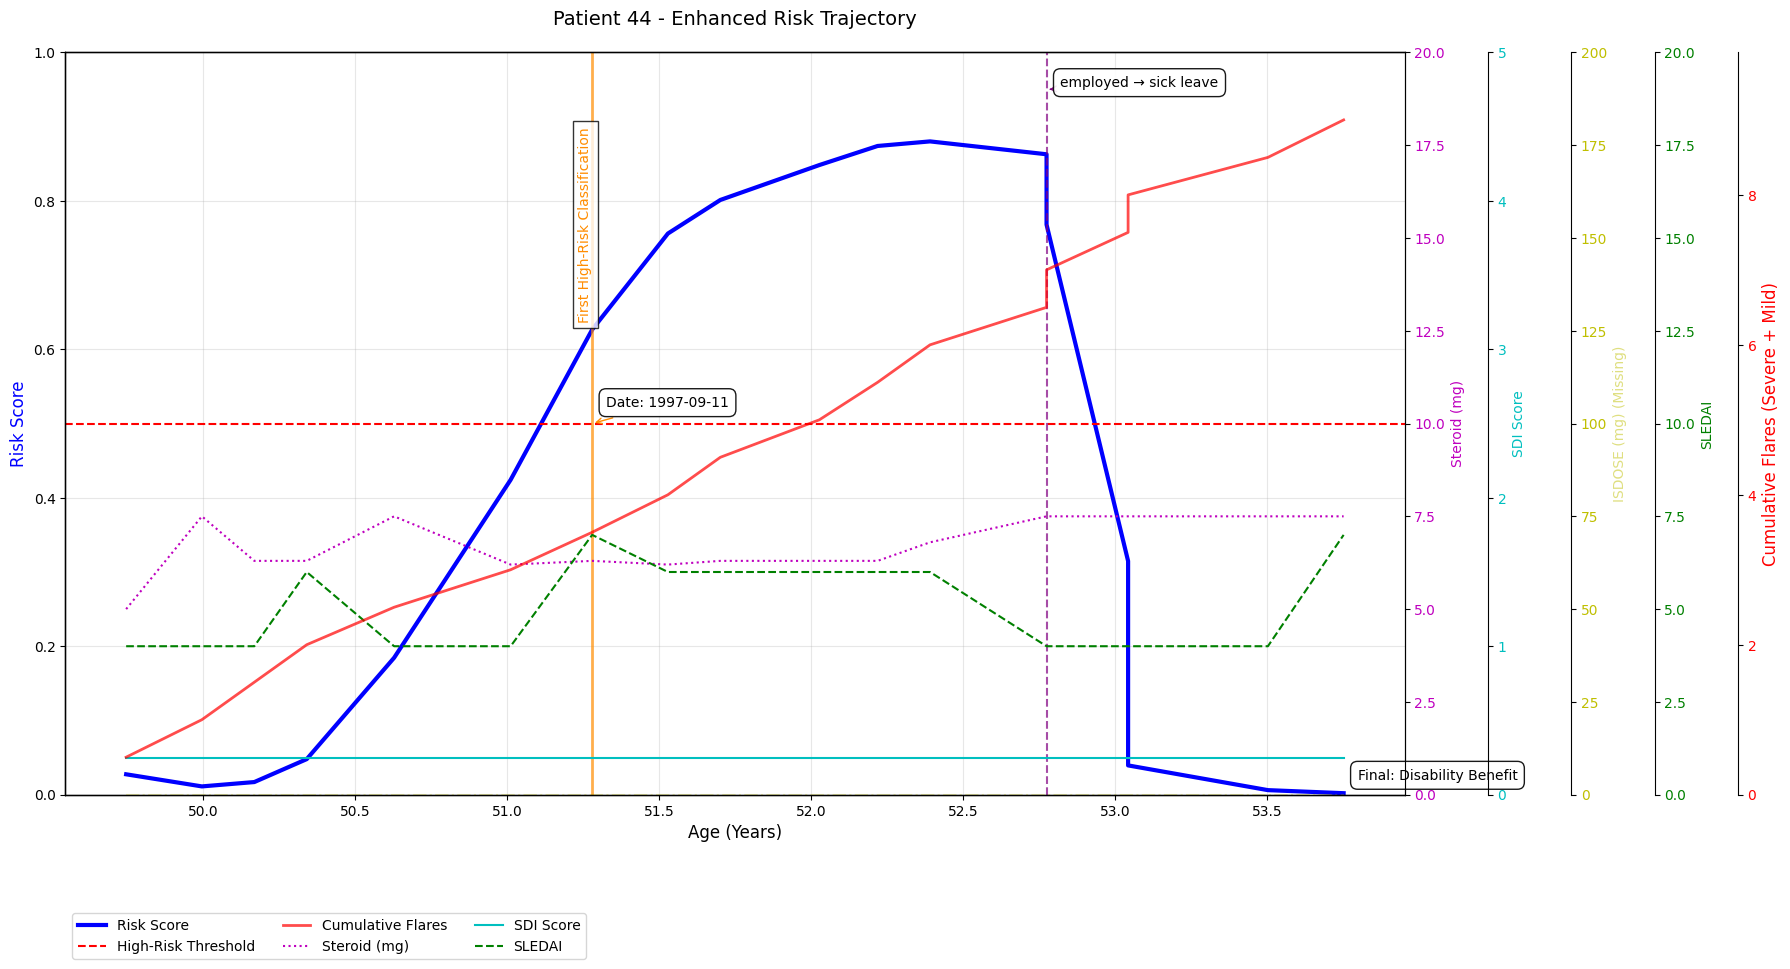

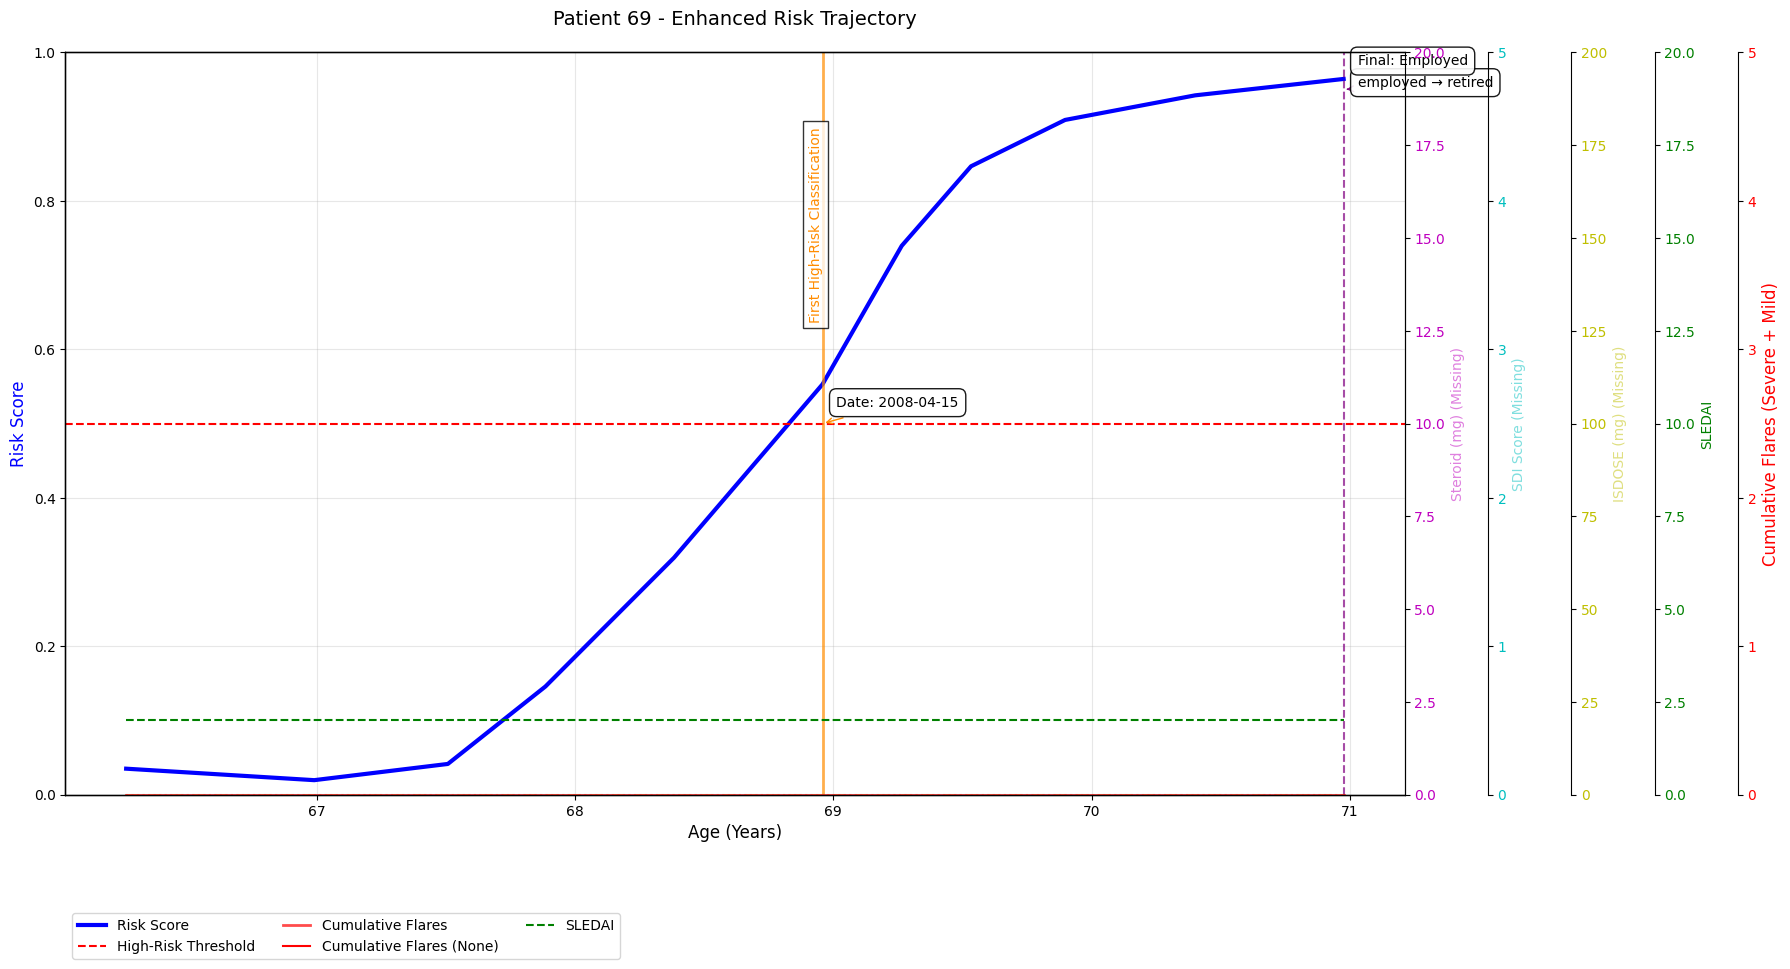

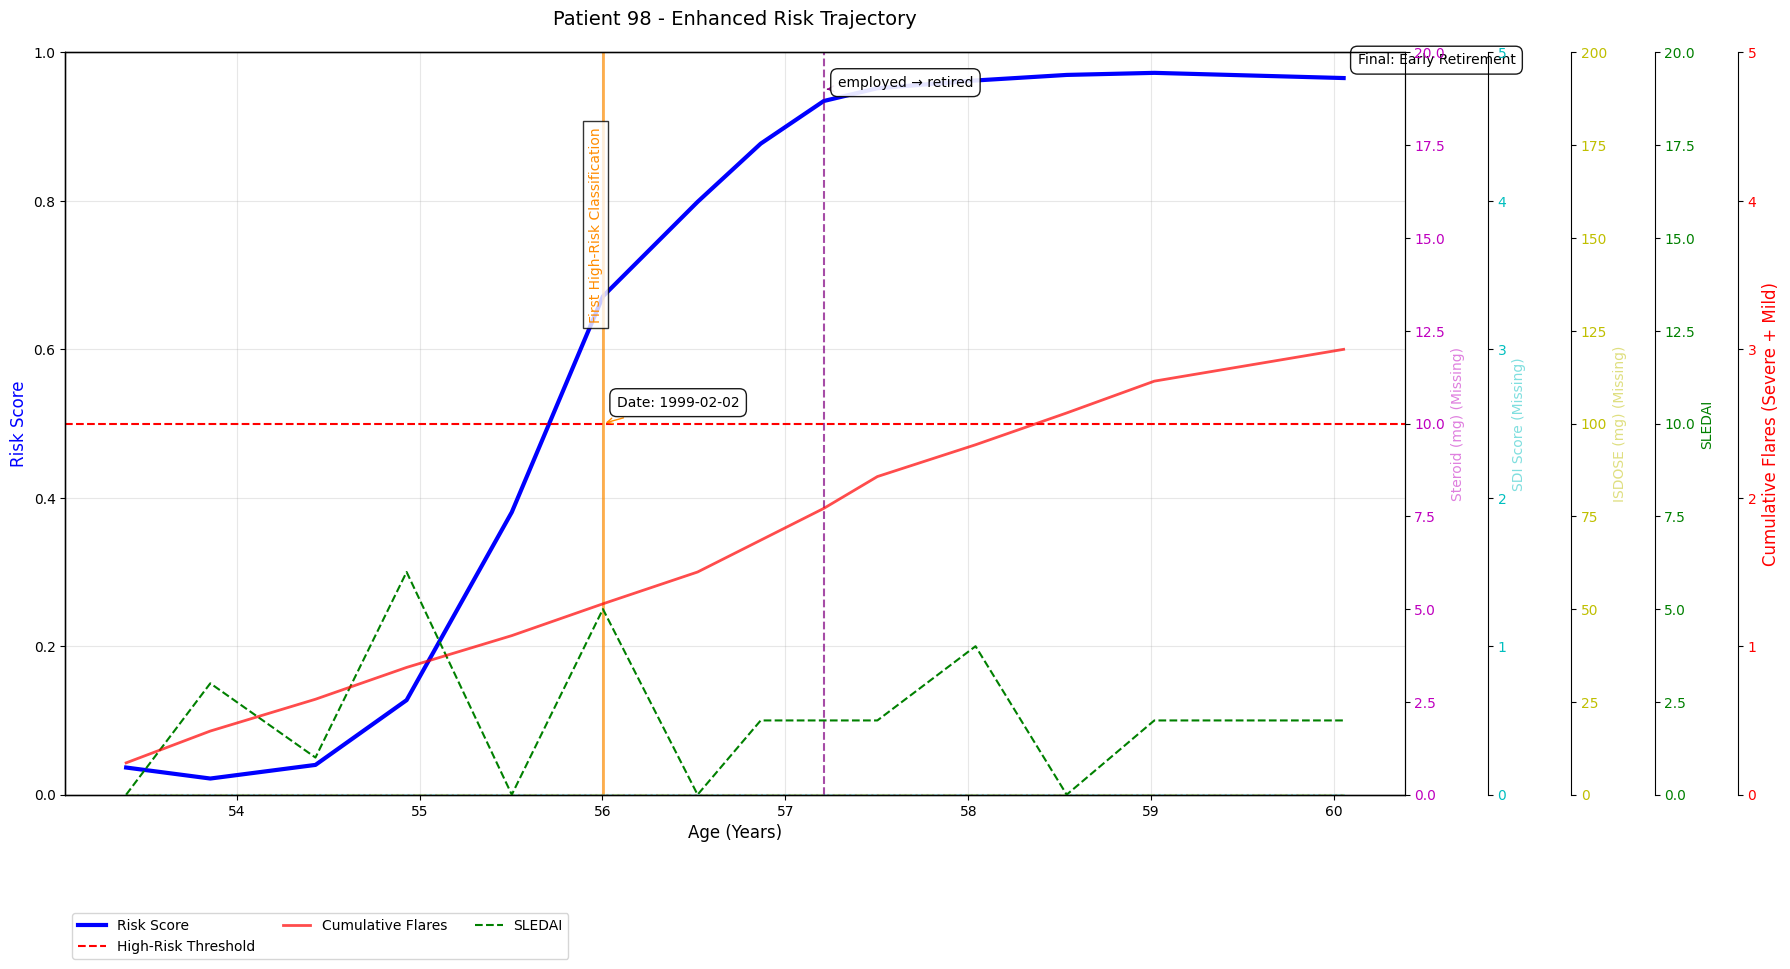

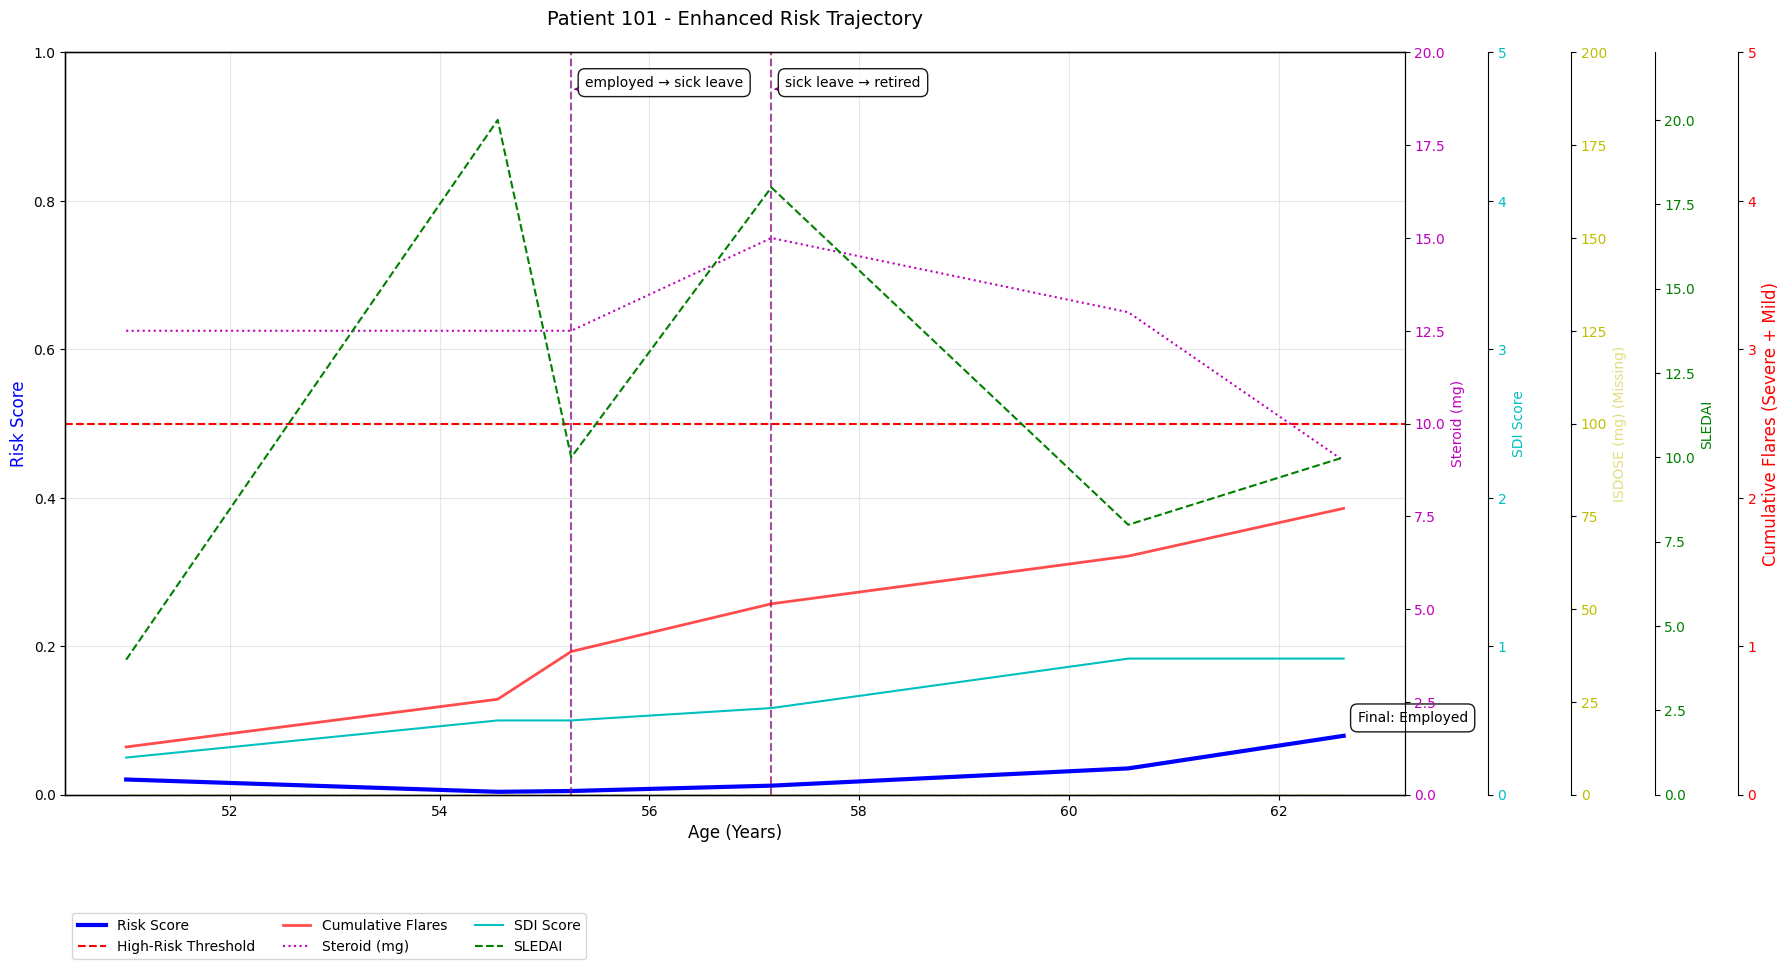

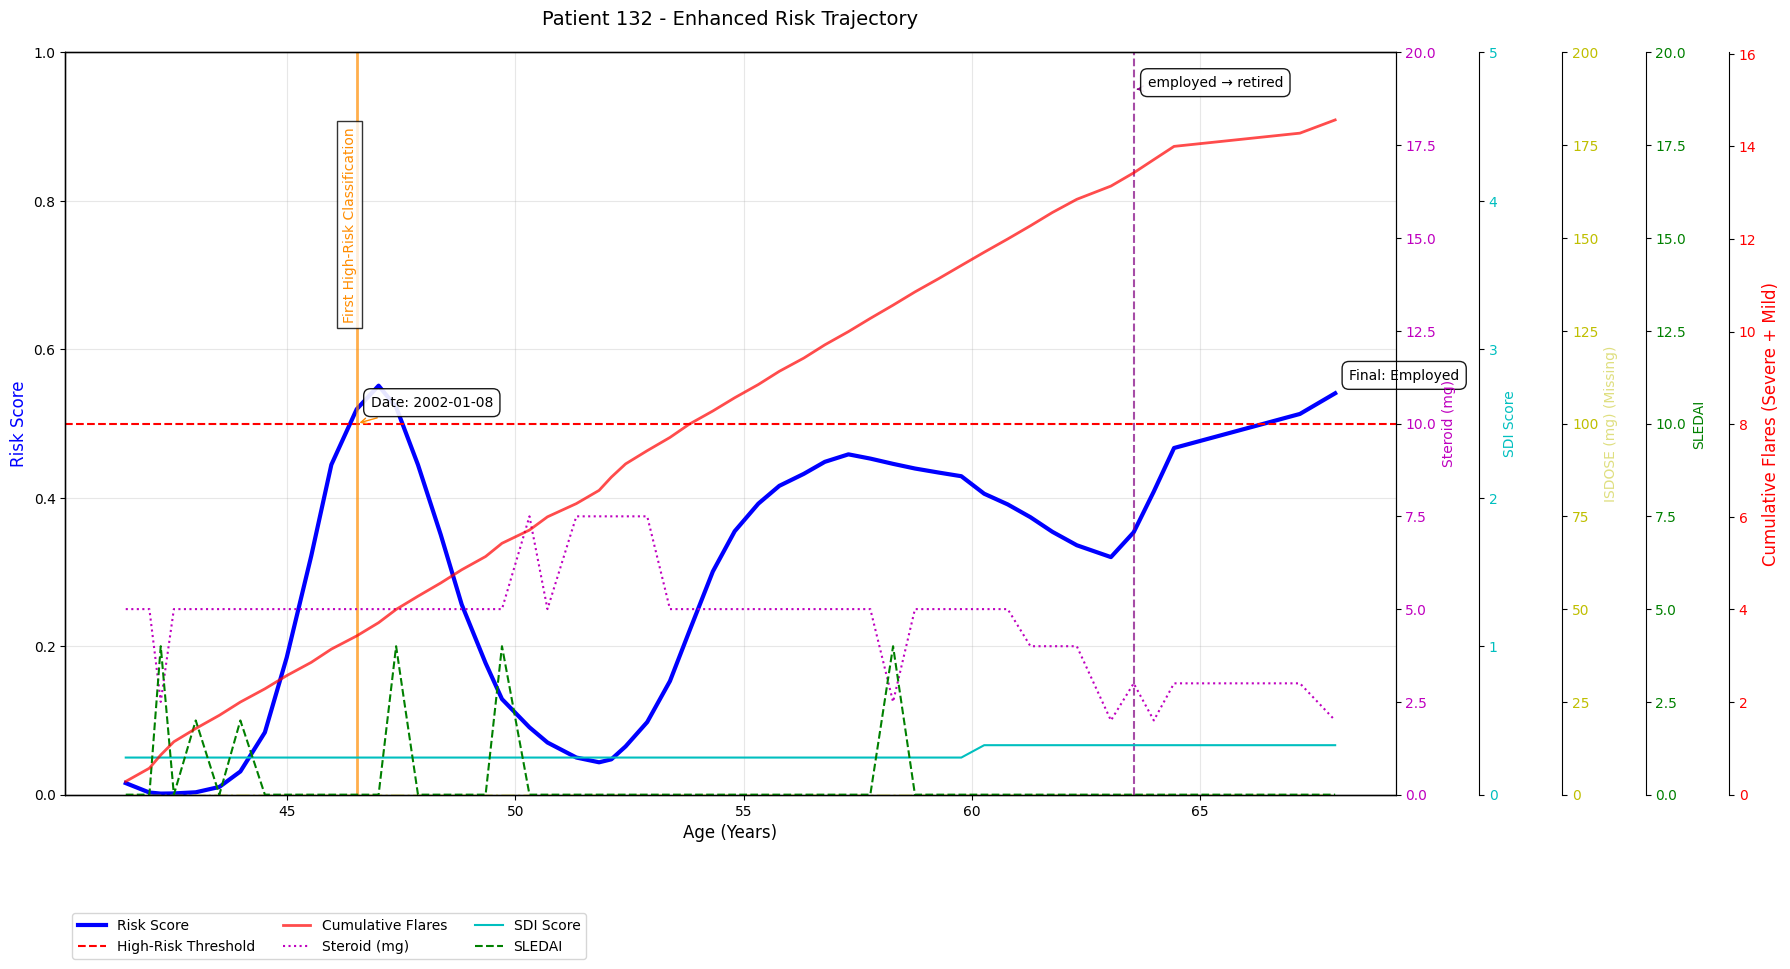

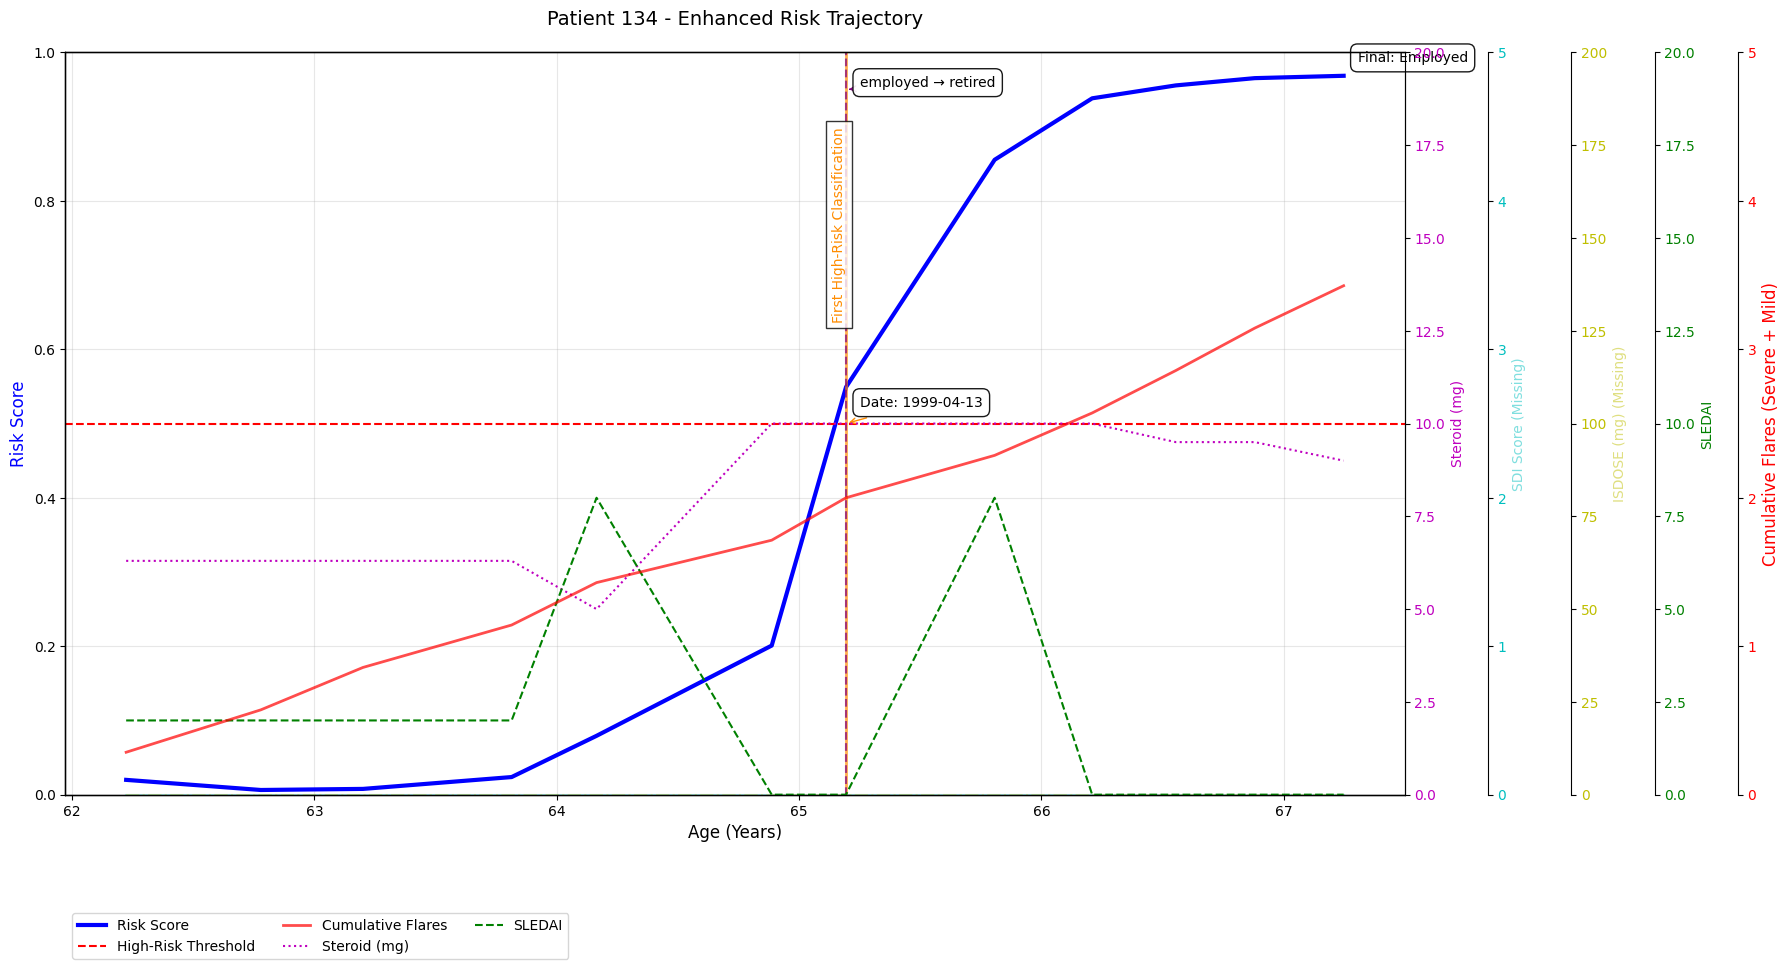

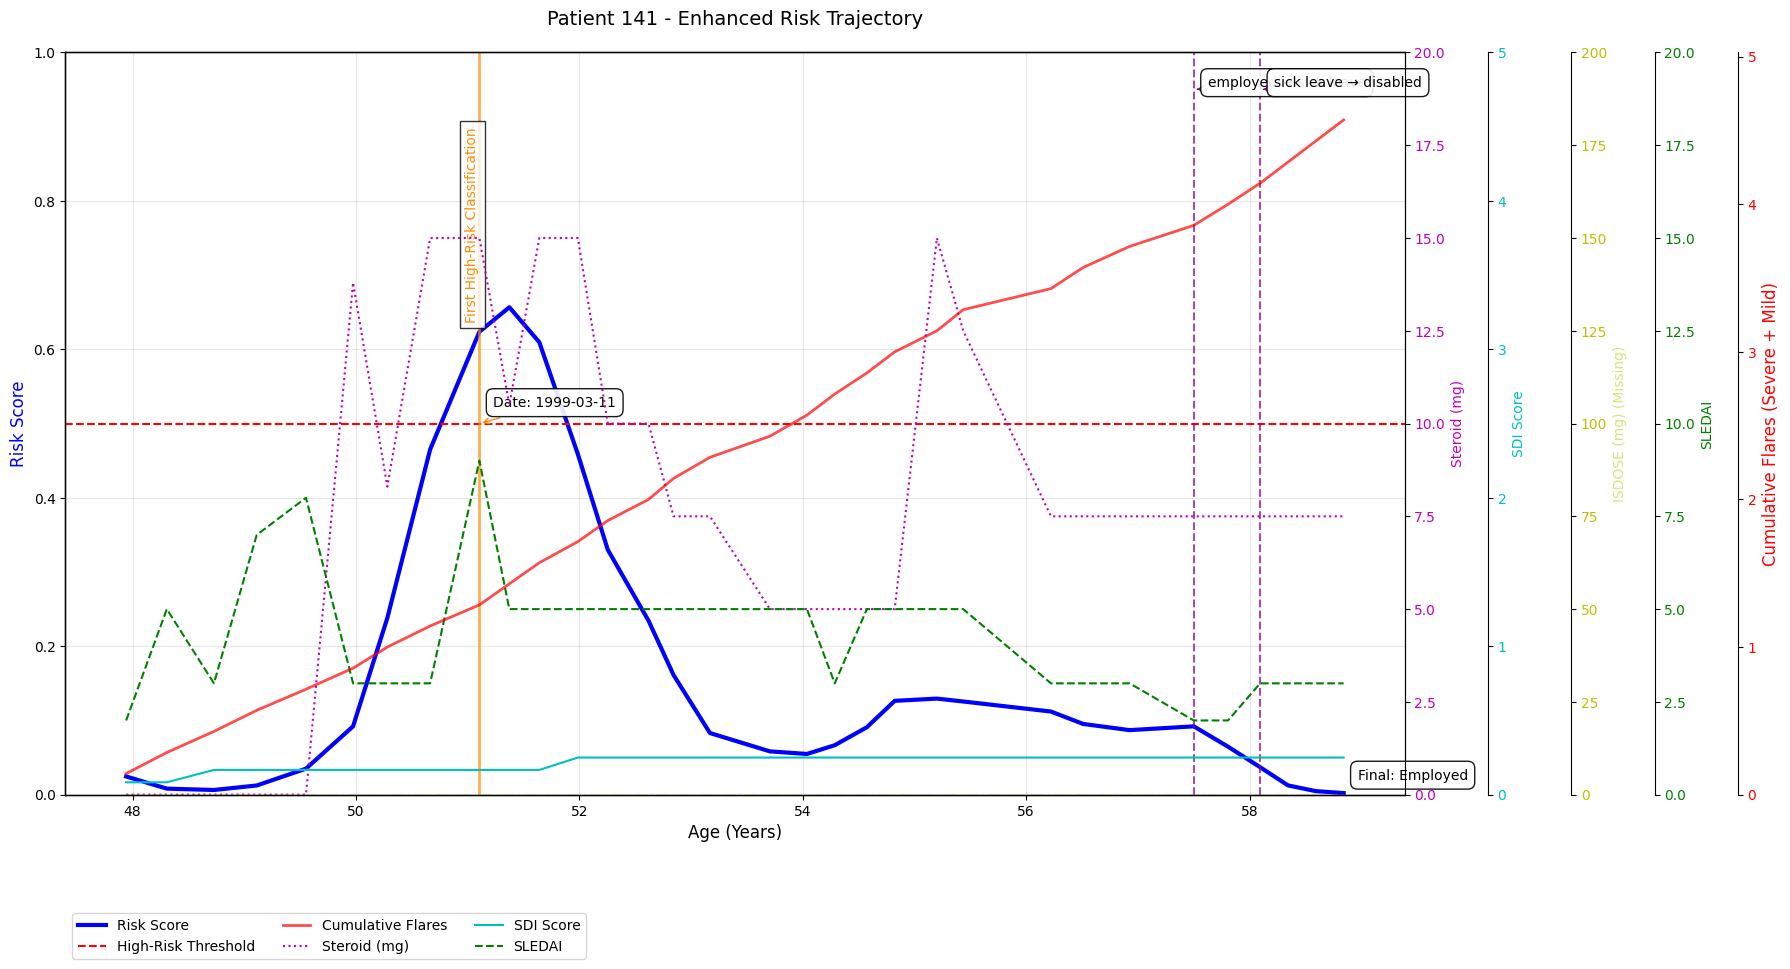

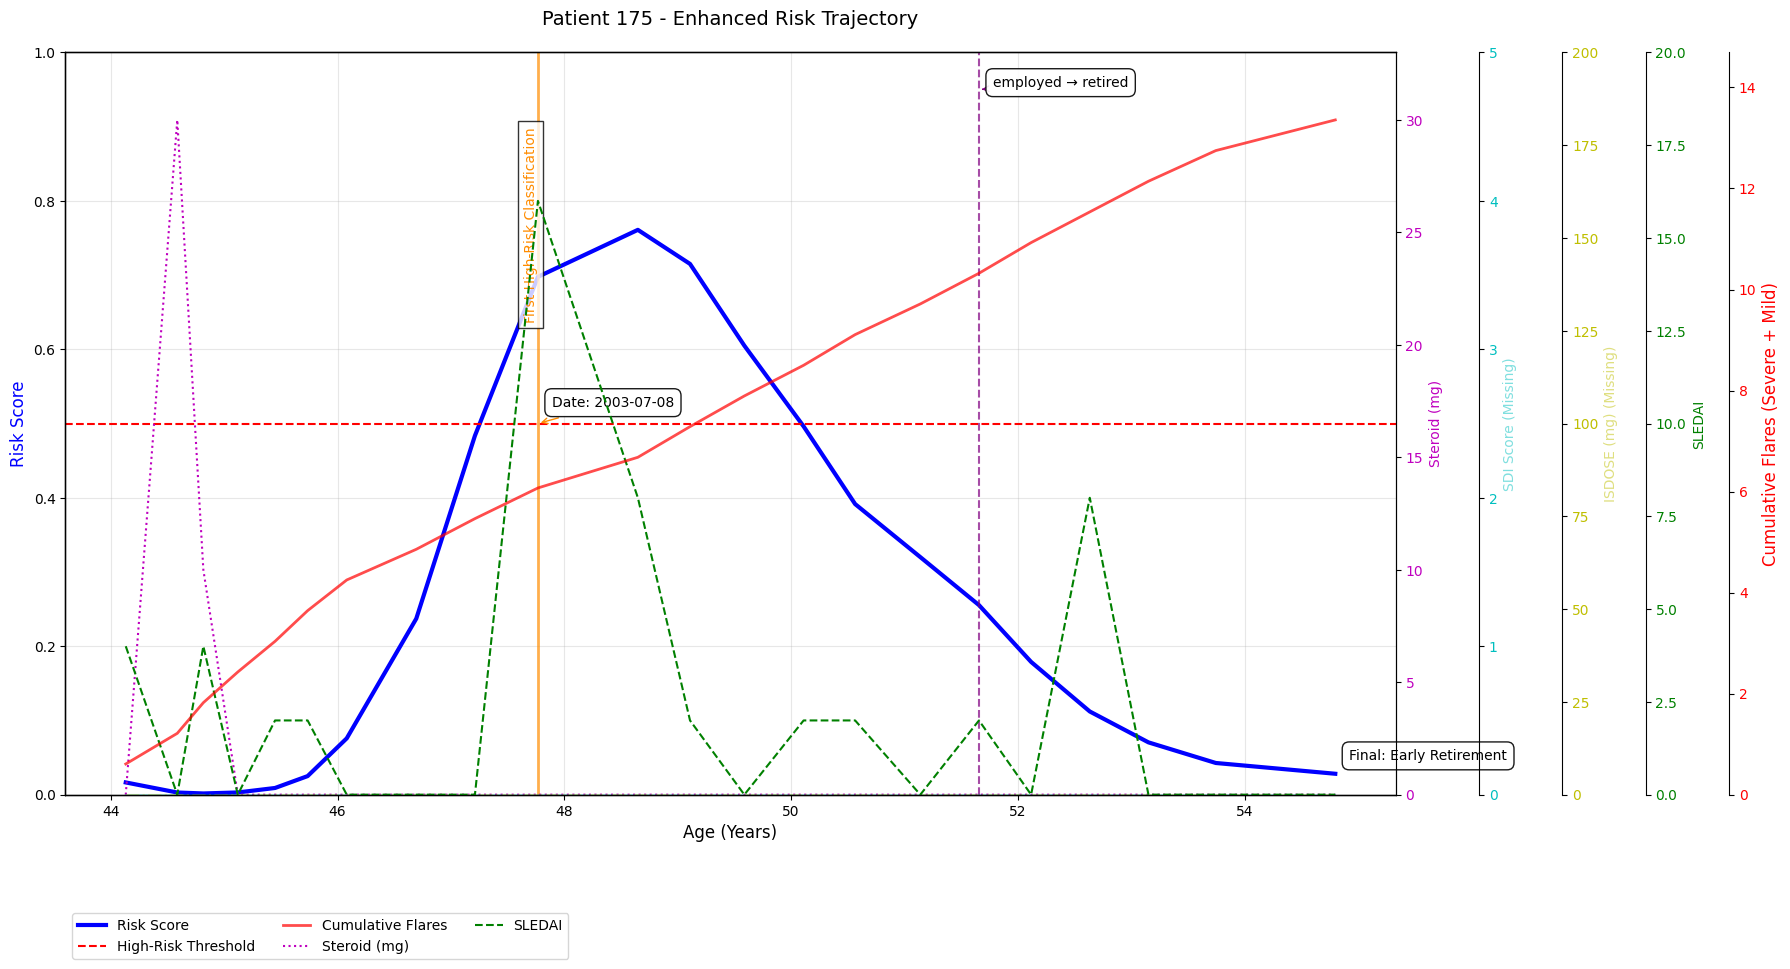

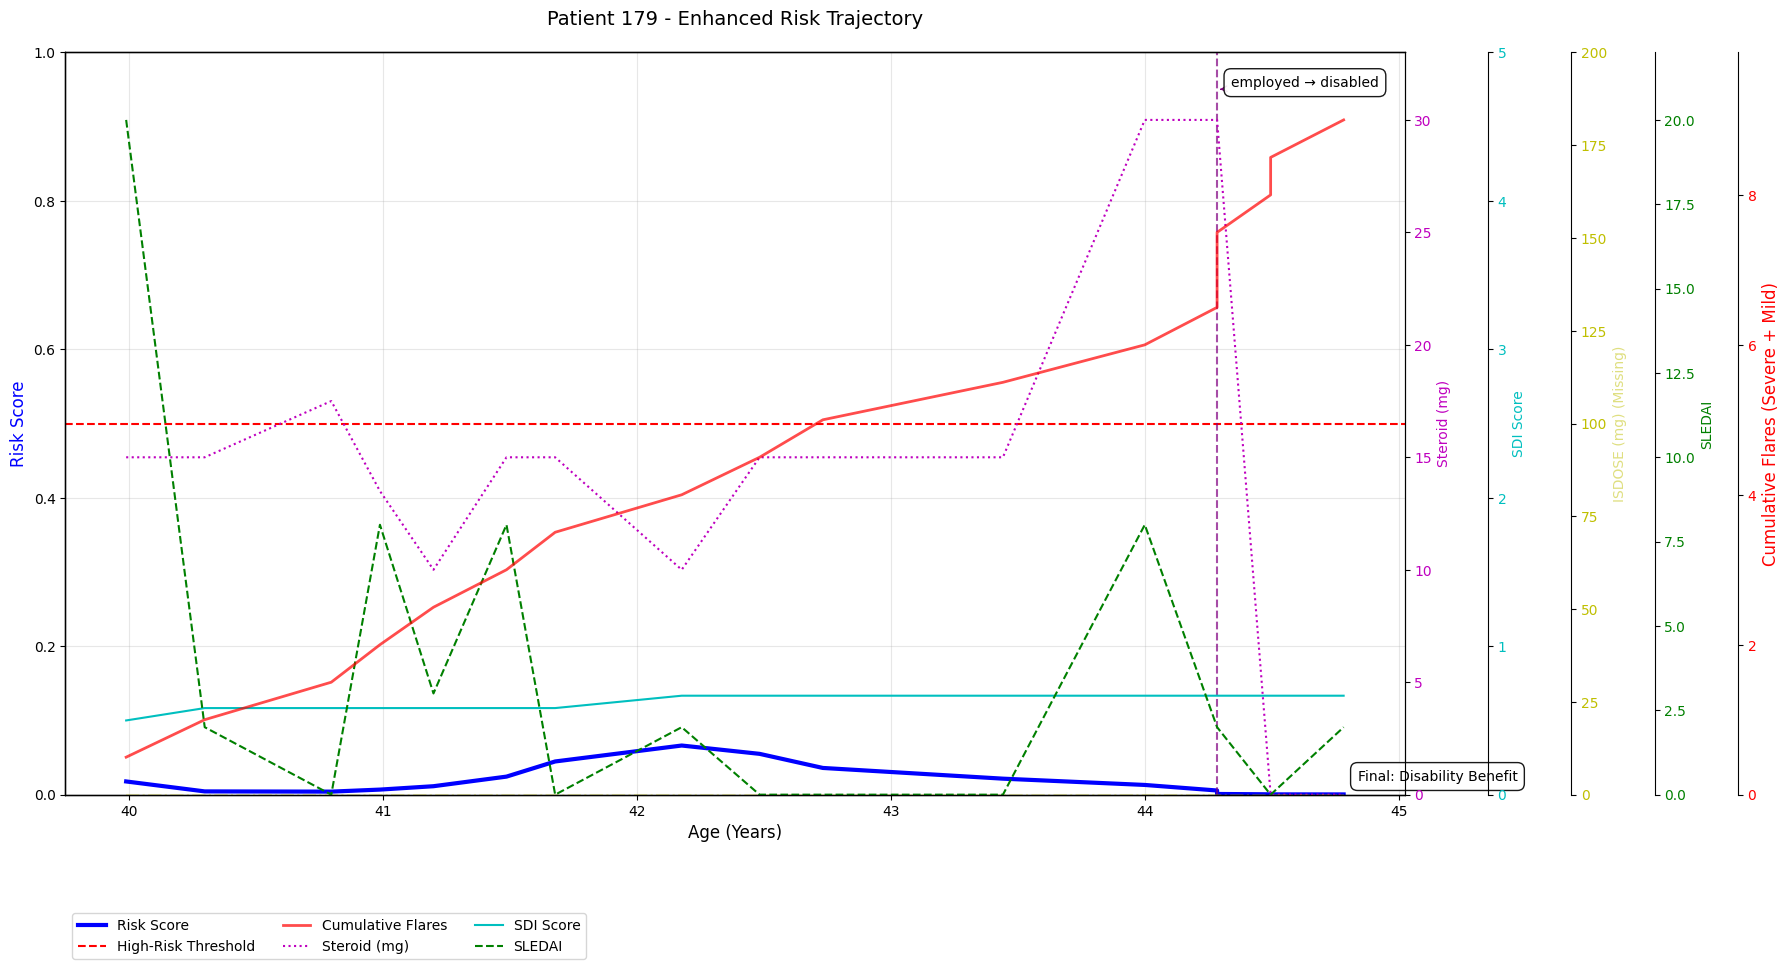

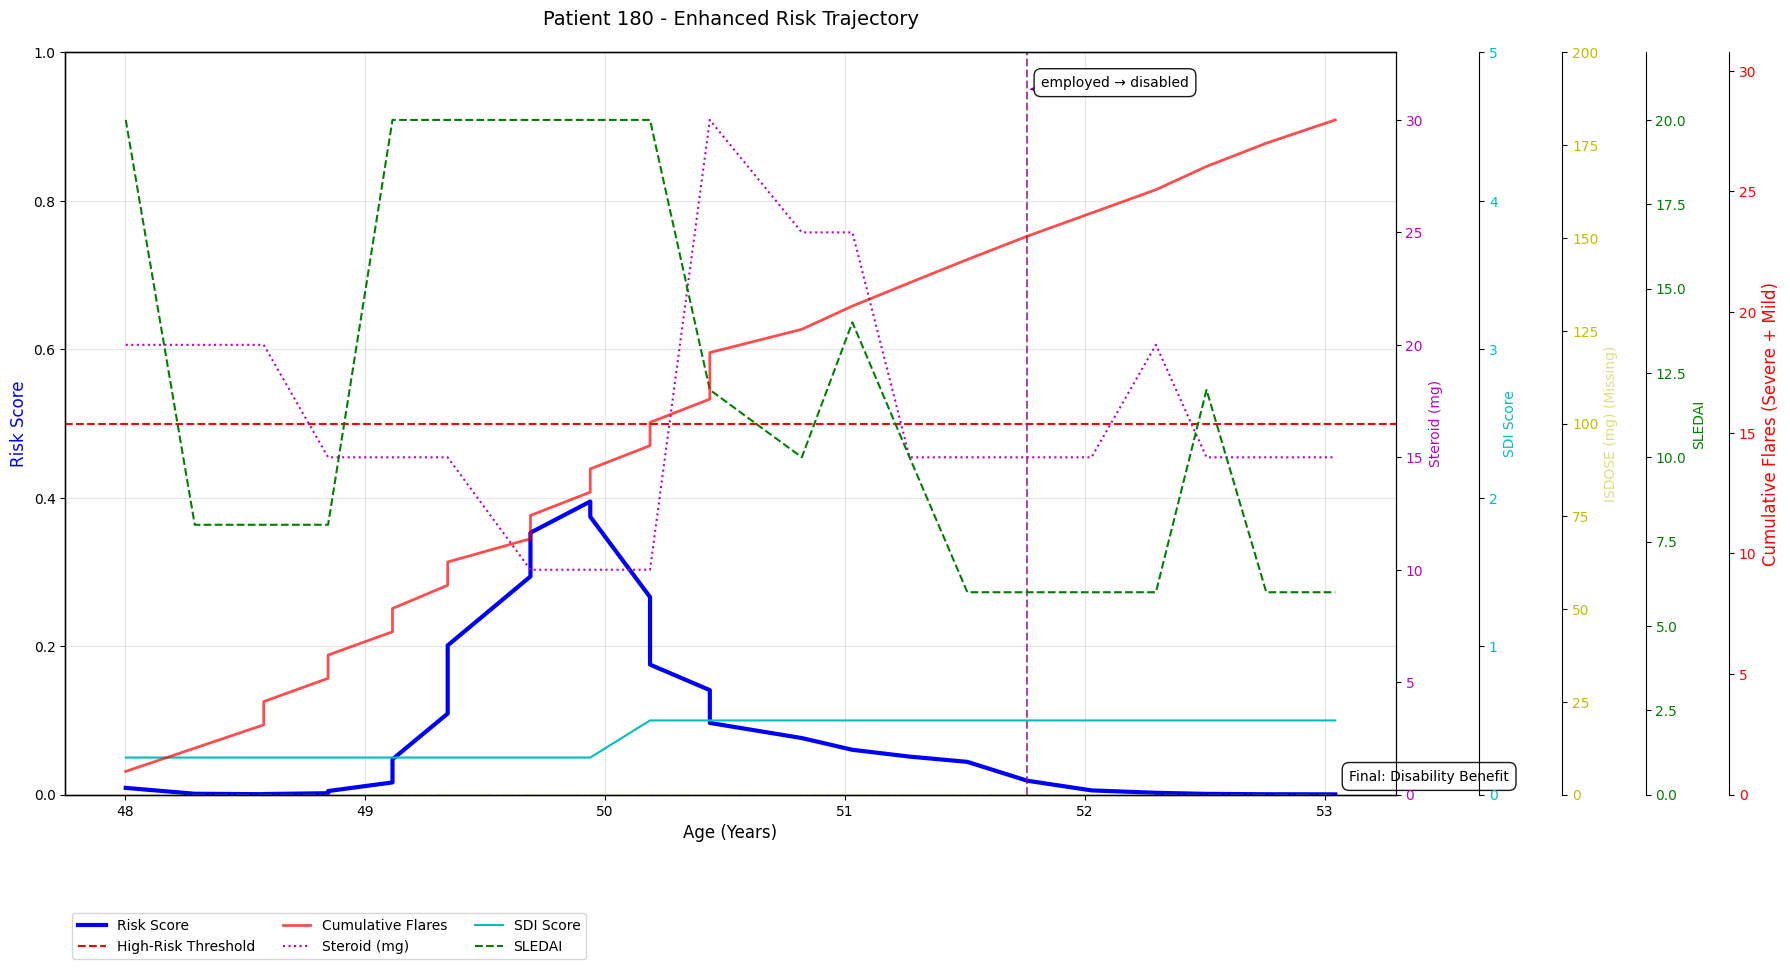

In [33]:
def plot_high_risk_trajectory_age_xaxis(pid, data, model, features, scaler):
    """Enhanced trajectory plot with:
    1. Enhanced risk score as primary blue line
    2. Cumulative flares on rightmost axis (0-5 range)
    3. Proper immunosuppressant dose visualization
    4. Unscaled coefficients
    5. Vertical line marking when patient was first classified as high risk
    """
    patient_data = data[data['PTNO'] == pid].sort_values('ASSDT')
    
    # Calculate age
    if 'BIRTHDT' in patient_data.columns:
        patient_data['Age'] = (patient_data['ASSDT'] - patient_data['BIRTHDT']).dt.days / 365.25
    else:
        patient_data['Age'] = (patient_data['ASSDT'] - patient_data['ASSDT'].min()).dt.days / 365.25
    
    # Get risk predictions - ensure we only use the same number of records as patient_data
    seq_length = min(len(patient_data), X.shape[1]) if hasattr(X, 'shape') else len(patient_data)
    risk_df = predict_risk_over_time(model, patient_data, features, seq_length)
    risk_df['Age'] = patient_data['Age'].values[:len(risk_df)]  # Ensure same length
    
    # Calculate when the patient was first classified as high risk
    threshold = risk_df['Threshold_Used'].iloc[0] if 'Threshold_Used' in risk_df.columns else 0.5
    high_risk_points = risk_df[risk_df['Risk_Score'] >= threshold]
    
    if not high_risk_points.empty:
        first_high_risk_age = high_risk_points['Age'].iloc[0]
        # Get the corresponding date safely
        matching_records = patient_data[patient_data['Age'] >= first_high_risk_age]
        if not matching_records.empty:
            first_high_risk_date = matching_records.iloc[0]['ASSDT']
        else:
            first_high_risk_date = None
    else:
        first_high_risk_age = None
        first_high_risk_date = None
    
    # Calculate cumulative flares if available
    if all(col in patient_data.columns for col in ['severe_flares', 'mild_flares']):
        risk_df['Cumulative_Flares'] = (patient_data['severe_flares'].fillna(0) + 
                                    patient_data['mild_flares'].fillna(0)).cumsum()[:len(risk_df)]
        has_flares = True
    else:
        risk_df['Cumulative_Flares'] = 0
        has_flares = False
    
    # Create figure with primary and secondary axes
    fig, ax1 = plt.subplots(figsize=(18, 10))
    
    # Plot ENHANCED risk score (blue line)
    if 'Enhanced_Risk_Score' in risk_df.columns:
        ax1.plot(risk_df['Age'], risk_df['Enhanced_Risk_Score'], 'b-', 
                label='Enhanced Risk Score', linewidth=3)
    else:
        ax1.plot(risk_df['Age'], risk_df['Risk_Score'], 'b-', 
                label='Risk Score', linewidth=3)
    
    ax1.set_xlabel('Age (Years)', fontsize=12)
    ax1.set_ylabel('Risk Score', color='b', fontsize=12)
    ax1.set_ylim(0, 1)
    ax1.grid(True, alpha=0.3)
    
    # Mark high-risk threshold
    ax1.axhline(y=threshold, color='r', linestyle='--', label='High-Risk Threshold')
    
    # Draw vertical line at first high-risk classification
    if first_high_risk_age is not None:
        ax1.axvline(x=first_high_risk_age, color='darkorange', linestyle='-', linewidth=2, alpha=0.7)
        ax1.text(first_high_risk_age, 0.9, 'First High-Risk Classification', rotation=90,
                ha='right', va='top', color='darkorange', bbox=dict(facecolor='white', alpha=0.8))
        
        # Add annotation with date
        if first_high_risk_date is not None:
            ax1.annotate(
                f"Date: {first_high_risk_date.strftime('%Y-%m-%d')}",
                xy=(first_high_risk_age, threshold),
                xytext=(10, 10),
                textcoords='offset points',
                ha='left',
                va='bottom',
                bbox=dict(boxstyle='round,pad=0.5', fc='white', alpha=0.9),
                arrowprops=dict(arrowstyle='->', color='darkorange')
            )

    # [Rest of the function remains the same...]
    # Standard clinical markers with guaranteed display
    clinical_markers = {
        'Steroid': {
            'values': risk_df['Steroid_Dose'].fillna(0) if 'Steroid_Dose' in risk_df else np.zeros(len(risk_df)),
            'color': 'm',
            'style': ':',
            'label': 'Steroid (mg)',
            'scale': 1,
            'default_max': 20
        },
        'SDI': {
            'values': risk_df['SDI'].fillna(0) if 'SDI' in risk_df else np.zeros(len(risk_df)),
            'color': 'c',
            'style': '-',
            'label': 'SDI Score',
            'scale': 1,
            'default_max': 5
        },
        'Immunosuppressant': {
            'values': risk_df['ISDOSE'].fillna(0) if 'ISDOSE' in risk_df else np.zeros(len(risk_df)),
            'color': 'y',
            'style': '-.',
            'label': 'ISDOSE (mg)',
            'scale': 1,
            'default_max': 200
        },
        'SLEDAI': {
            'values': risk_df['SLEDAI'].fillna(0) if 'SLEDAI' in risk_df else np.zeros(len(risk_df)),
            'color': 'g',
            'style': '--',
            'label': 'SLEDAI',
            'scale': 1,
            'default_max': 20
        }
    }
    
    # [Rest of the plotting code remains the same...]
    # Create right axes for all clinical markers
    axes_right = {}
    offset = 60
    
    for i, (marker_name, params) in enumerate(clinical_markers.items()):
        ax = ax1.twinx()
        ax.spines['right'].set_position(('outward', offset*i))
        
        # Plot the line (even if all zeros)
        line = ax.plot(risk_df['Age'], params['values'], 
                    color=params['color'], 
                    linestyle=params['style'], 
                    label=params['label'])
        
        ax.set_ylabel(params['label'], color=params['color'])
        ax.tick_params(axis='y', labelcolor=params['color'])
        
        # Set consistent y-limits (0 to default_max)
        ax.set_ylim(0, params['default_max'])
        
        # Highlight if data is all zeros/missing
        if np.all(params['values'] == 0):
            line[0].set_alpha(0.3)  # Make line faint if no real data
            ax.set_ylabel(f"{params['label']} (Missing)", color=params['color'], alpha=0.5)
        else:
            # Auto-scale if we have real data
            clean_vals = params['values'][np.isfinite(params['values'])]
            if len(clean_vals) > 0:
                ymax = max(params['default_max'], np.max(clean_vals) * 1.1)
                ax.set_ylim(0, ymax)
        
        axes_right[marker_name] = ax
    
    # Add cumulative flares axis (rightmost)
    if has_flares or 'Cumulative_Flares' in risk_df.columns:
        flare_ax = ax1.twinx()
        # Position flares axis as the rightmost (after all others)
        num_markers = len(clinical_markers)
        flare_ax.spines['right'].set_position(('outward', offset*num_markers))
        
        flare_ax.plot(risk_df['Age'], risk_df['Cumulative_Flares'], 'r-', 
                    label='Cumulative Flares', linewidth=2, alpha=0.7)
        flare_ax.set_ylabel('Cumulative Flares (Severe + Mild)', color='r', fontsize=12)
        flare_ax.tick_params(axis='y', labelcolor='r')
        
        # Set y-limits (0-5 when no flares, or auto-scaled when present)
        if has_flares and risk_df['Cumulative_Flares'].max() > 0:
            flare_max = max(5, risk_df['Cumulative_Flares'].max() * 1.1)
            flare_ax.set_ylim(0, flare_max)
        else:
            flare_ax.set_ylim(0, 5)  # Default 0-5 range when no flares
            flare_ax.plot([], [], 'r-', label='Cumulative Flares (None)')  # Add to legend
    
    # Enhanced employment transition markers
    if 'EMPf' in patient_data.columns:
        for i in range(1, len(patient_data)):
            if patient_data['EMPf'].iloc[i] != patient_data['EMPf'].iloc[i-1]:
                transition_age = patient_data['Age'].iloc[i]
                prev_status = patient_data['EMPf'].iloc[i-1]
                new_status = patient_data['EMPf'].iloc[i]
                
                ax1.axvline(x=transition_age, color='purple', linestyle='--', alpha=0.7, linewidth=1.5)
                ax1.annotate(
                    f"{prev_status} → {new_status}",
                    xy=(transition_age, 0.95),
                    xytext=(10, 10),
                    textcoords='offset points',
                    ha='left',
                    va='top',
                    bbox=dict(boxstyle='round,pad=0.5', fc='white', alpha=0.9),
                    arrowprops=dict(arrowstyle='->', color='purple')
                )
    
    # Highlight first high-risk flag if available (this is different from algorithmic classification)
    if 'First_High_Risk_Date' in patient_data.columns and pd.notna(patient_data['First_High_Risk_Date'].iloc[0]):
        flag_age = (patient_data['First_High_Risk_Date'].iloc[0] - patient_data['BIRTHDT'].iloc[0]).days/365.25
        ax1.axvline(x=flag_age, color='darkgreen', linestyle=':', linewidth=2)
        ax1.text(flag_age, 0.8, 'First Risk Flag', rotation=90, 
                ha='right', va='top', color='darkgreen')
    
    # Final outcome annotation
    if 'end_state' in patient_data.columns:
        final_age = patient_data['Age'].iloc[-1]
        ax1.annotate(
            f"Final: {patient_data['end_state'].iloc[-1]}",
            xy=(final_age, risk_df['Risk_Score'].iloc[-1]),
            xytext=(10, 10),
            textcoords='offset points',
            bbox=dict(boxstyle='round,pad=0.5', fc='white', alpha=0.9)
        )
    
    # Add model coefficients information (unscaled)
    if hasattr(model, 'coef_') and scaler is not None:
        if hasattr(scaler, 'scale_'):
            unscaled_coef = model.coef_[0] / scaler.scale_
        else:
            unscaled_coef = model.coef_[0]
        
        coef_info = "Model Coefficients (Unscaled):\n" + "\n".join(
            [f"{feat}: {coef:.4f}" for feat, coef in zip(features, unscaled_coef)]
        )
        
        ax1.text(0.02, 0.98, coef_info,
                transform=ax1.transAxes,
                fontsize=9,
                verticalalignment='top',
                bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))
    
    # Combine legends
    lines1, labels1 = ax1.get_legend_handles_labels()
    lines_right = []
    labels_right = []
    
    for marker_name, ax in axes_right.items():
        lines, labels = ax.get_legend_handles_labels()
        if not np.all(clinical_markers[marker_name]['values'] == 0):
            lines_right.extend(lines)
            labels_right.extend(labels)
    
    # Add cumulative flares to legend if axis exists
    if 'flare_ax' in locals():
        flare_lines, flare_labels = flare_ax.get_legend_handles_labels()
        lines1.extend(flare_lines)
        labels1.extend(flare_labels)
    
    if lines_right:
        ax1.legend(lines1 + lines_right, labels1 + labels_right, 
                loc='upper left', bbox_to_anchor=(0, -0.15), ncol=3)
    else:
        ax1.legend(lines1, labels1, loc='upper left', bbox_to_anchor=(0, -0.15))
    
    plt.title(f'Patient {pid} - Enhanced Risk Trajectory', fontsize=14, pad=20)
    plt.tight_layout()
    plt.subplots_adjust(bottom=0.2)
    plt.show()

# Convert date columns to datetime if they're strings
date_cols = ['ASSDT', 'BIRTHDT', 'First_High_Risk_Date', 'Final_Outcome_Date']
for col in date_cols:
    if col in data.columns and data[col].dtype == object:
        data[col] = pd.to_datetime(data[col], errors='coerce')
    if col in high_risk_df.columns and high_risk_df[col].dtype == object:
        high_risk_df[col] = pd.to_datetime(high_risk_df[col], errors='coerce')
            
# Visualize example cases with age on x-axis
if not high_risk_df.empty:
    print("\nVisualizing High-Risk Patient Trajectories (Age on X-axis)...")
    for pid in high_risk_df['PTNO'][:10]:
        plot_high_risk_trajectory_age_xaxis(pid, data, model, features, scaler)
else:
    print("No high-risk patients to visualize.")

# New code

In [54]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import LabelEncoder, MinMaxScaler
from sklearn.model_selection import train_test_split
from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import classification_report, confusion_matrix, balanced_accuracy_score, cohen_kappa_score,precision_recall_curve
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import cross_val_predict
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout, Masking, BatchNormalization
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from tensorflow.keras.regularizers import l2
from tensorflow.keras.utils import to_categorical
from sklearn.model_selection import StratifiedKFold
from sklearn.utils import class_weight


# Load the data - removed duplicate load
data = pd.read_csv('sledatacut.csv', parse_dates=['ASSDT'], low_memory=False)

# Sort by patient and assessment date
data = data.sort_values(['PTNO', 'ASSDT'])

# Calculate time differences
data['time_since_first'] = data.groupby('PTNO')['ASSDT'].transform(
    lambda x: (x - x.min()).dt.days
)
data['time_since_last'] = data.groupby('PTNO')['ASSDT'].transform(
    lambda x: x.diff().dt.days.fillna(0)
)

# Convert categorical EMPf to numerical
emp_mapping = {v: k for k, v in enumerate(data['EMPf'].unique())}
data['EMP_numeric'] = data['EMPf'].map(emp_mapping)

# Encode the target (end_state)
label_encoder = LabelEncoder()
data['end_state_encoded'] = label_encoder.fit_transform(data['end_state'])

# Encode steroid categories (Low/Medium/High)
steroid_mapping = {'Low': 0, 'Medium': 1, 'High': 2}
data['STEROID_CAT_numeric'] = data['STEROID_CAT'].map(steroid_mapping)

# Features to use - including SDI (score_n) along with flares and steroid categories
features = ['EMP_numeric', 'severe_flares', 'mild_flares', 
            'STEROID_CAT_numeric', 'ISDOSE', 'INCEPT', 'AMDOSE', 
            'age_at_record', 'time_since_last', 'time_since_first', 
            'visit_num', 'score_n']  # Added score_n (SDI)

# Add total flares feature
data['total_flares'] = data['severe_flares'] + data['mild_flares']

# Add interaction terms between important features
data['steroid_flare_interaction'] = data['STEROID_CAT_numeric'] * data['total_flares']
data['sdi_flare_interaction'] = data['score_n'] * data['total_flares']

# Add temporal features
data['flares_per_month'] = data['total_flares'] / (data['time_since_first']/30 + 1)  # +1 to avoid division by zero

# Correct SDI change rate calculation - using time_since_last instead of index
data['sdi_change_rate'] = data.groupby('PTNO', group_keys=False).apply(
    lambda x: x['score_n'].diff().fillna(0) / (x['time_since_last']/30 + 1e-6)  # Small constant to avoid division by zero
)

# Update features list
features += ['total_flares', 'steroid_flare_interaction', 'sdi_flare_interaction', 
             'flares_per_month', 'sdi_change_rate']

# Identify categorical columns (non-numeric)
categorical_cols = data[features].select_dtypes(include=['object', 'category']).columns

# Label encode categorical columns
for col in categorical_cols:
    le = LabelEncoder()
    data[col] = le.fit_transform(data[col].astype(str))

# Fill NA values - for flares and SDI we'll assume 0 if missing
flare_cols = ['severe_flares', 'mild_flares']
data[flare_cols] = data[flare_cols].fillna(0)
data['score_n'] = data['score_n'].fillna(0)  # SDI
data[features] = data[features].fillna(0)

# Normalize features
scaler = MinMaxScaler()
data[features] = scaler.fit_transform(data[features])

# Create sequences for each patient
def create_sequences(data, features, max_seq_length=None):
    patients = data['PTNO'].unique()
    num_features = len(features)
    
    if not max_seq_length:
        max_seq_length = data.groupby('PTNO').size().max()
    
    X = np.zeros((len(patients), max_seq_length, num_features))
    y = np.zeros(len(patients))
    seq_lengths = np.zeros(len(patients))
    
    for i, patient in enumerate(patients):
        patient_data = data[data['PTNO'] == patient].sort_values('ASSDT')
        seq_len = len(patient_data)
        seq_lengths[i] = seq_len
        
        # Fill the sequence data
        X[i, :seq_len, :] = patient_data[features].values
        
        # Get the end_state label (last record)
        y[i] = patient_data['end_state_encoded'].iloc[-1]
    
    return X, to_categorical(y), seq_lengths

# Create sequences

# Create sequences
X, y, seq_lengths = create_sequences(data, features)

# Convert y from one-hot encoded to labels for stratified k-fold
y_labels = np.argmax(y, axis=1) if len(y.shape) > 1 else y  # Handle both one-hot and label encoded

# Initialize cross-validation
n_splits = 5
skf = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=42)

# Store results
cv_results = {
    'val_accuracy': [],
    'val_loss': [],
    'test_preds': [],
    'models': []
}

# Create a test set that will be used for final evaluation
X_train_all, X_test, y_train_all, y_test, seq_train_all, seq_test = train_test_split(
    X, y, seq_lengths, test_size=0.2, random_state=42, stratify=y_labels)

# Cross-validation loop (on the training data only)
for fold, (train_idx, val_idx) in enumerate(skf.split(X_train_all, np.argmax(y_train_all, axis=1))):
    print(f"\nTraining fold {fold + 1}/{n_splits}")
    
    # Split data
    X_train, X_val = X_train_all[train_idx], X_train_all[val_idx]
    y_train, y_val = y_train_all[train_idx], y_train_all[val_idx]
    

    # Calculate class weights - FIXED VERSION
    y_train_labels = np.argmax(y_train, axis=1)  # Convert from one-hot to labels
    classes = np.unique(y_train_labels)
    class_weights = compute_class_weight(
        'balanced',
        classes=classes,
        y=y_train_labels
    )
    class_weight_dict = {i: weight for i, weight in enumerate(class_weights)}

    # Build model - rest of your model code remains the same
    model = Sequential([
        Masking(mask_value=0., input_shape=(None, len(features))),
        LSTM(128, return_sequences=True, kernel_regularizer=l2(0.01)),
        BatchNormalization(),
        Dropout(0.3),
        LSTM(64, kernel_regularizer=l2(0.01)),
        BatchNormalization(),
        Dropout(0.3),
        Dense(32, activation='relu', kernel_regularizer=l2(0.01)),
        Dense(y.shape[1], activation='softmax')
    ])
        
    optimizer = Adam(learning_rate=0.001)
    model.compile(optimizer=optimizer,
                 loss='categorical_crossentropy',
                 metrics=['accuracy'])
    
    callbacks = [
        EarlyStopping(monitor='val_loss', patience=15, restore_best_weights=True),
        ReduceLROnPlateau(monitor='val_loss', factor=0.2, patience=5, min_lr=1e-6)
    ]
    
    # Train model
    history = model.fit(
        X_train,
        y_train,
        batch_size=32,
        epochs=100,
        validation_data=(X_val, y_val),
        callbacks=callbacks,
        class_weight=class_weight_dict,
        verbose=1
    )
    
    # Store results
    val_loss, val_acc = model.evaluate(X_val, y_val, verbose=0)
    cv_results['val_accuracy'].append(val_acc)
    cv_results['val_loss'].append(val_loss)
    cv_results['models'].append(model)
    
    print(f"Fold {fold + 1} - Val Accuracy: {val_acc:.4f}, Val Loss: {val_loss:.4f}")

# Print cross-validation results
print("\nCross-Validation Results:")
print(f"Mean Val Accuracy: {np.mean(cv_results['val_accuracy']):.4f} (±{np.std(cv_results['val_accuracy']):.4f})")
print(f"Mean Val Loss: {np.mean(cv_results['val_loss']):.4f} (±{np.std(cv_results['val_loss']):.4f})")

# Ensemble predictions from all folds on test set
test_preds = np.zeros((len(X_test), y.shape[1]))
for model in cv_results['models']:
    test_preds += model.predict(X_test, verbose=0)
test_preds /= n_splits

def adjust_predictions(y_scores, y_true, desired_recall=0.8):
    """Adjust predictions to meet recall target"""
    # Convert one-hot encoded y_true to binary labels if needed
    if len(y_true.shape) > 1 and y_true.shape[1] > 1:
        y_true_binary = np.argmax(y_true, axis=1)
    else:
        y_true_binary = y_true
    
    # Get probabilities for positive class
    if len(y_scores.shape) > 1 and y_scores.shape[1] > 1:
        y_scores = y_scores[:, 1]  # Take probabilities for positive class
    
    precisions, recalls, thresholds = precision_recall_curve(y_true_binary, y_scores)
    
    # Find threshold that gives at least desired recall
    viable_thresholds = thresholds[recalls[:-1] >= desired_recall]
    if len(viable_thresholds) > 0:
        optimal_threshold = viable_thresholds[0]  # Most conservative threshold meeting recall
    else:
        optimal_threshold = thresholds[np.argmax(recalls)]  # Best possible recall
    
    # Apply threshold
    adjusted_preds = (y_scores >= optimal_threshold).astype(int)
    
    return adjusted_preds, optimal_threshold

# Get last observations for RF
def get_last_observations(X, seq_lengths, features):
    last_obs = []
    for i in range(X.shape[0]):
        seq_len = int(seq_lengths[i])
        last_obs.append(X[i, seq_len-1, :])
    return np.array(last_obs)

X_last = get_last_observations(X_train_all, seq_train_all, features)

# Train RF with cross-validation
rf = RandomForestClassifier(n_estimators=200, class_weight='balanced', random_state=42)
rf.fit(X_last, np.argmax(y_train_all, axis=1))  # Train on full training data

# Get RF predictions for test set
X_test_last = get_last_observations(X_test, seq_test, features)
rf_test_pred = rf.predict_proba(X_test_last)

# Combine with LSTM predictions (weighted average)
final_pred_probs = 0.7 * test_preds + 0.3 * rf_test_pred

# Adjust predictions to optimize recall
# Evaluation for multi-class classification
y_true_classes = np.argmax(y_test, axis=1)
y_pred_classes = np.argmax(final_pred_probs, axis=1)

# Evaluation metrics
print("\nFinal Ensemble Evaluation Metrics:")
print(f"Balanced Accuracy: {balanced_accuracy_score(y_true_classes, y_pred_classes):.3f}")
print(f"Cohen's Kappa: {cohen_kappa_score(y_true_classes, y_pred_classes):.3f}")

# Classification report
print("\nClassification Report:")
print(classification_report(
    y_true_classes, 
    y_pred_classes, 
    target_names=label_encoder.classes_
))

# Confusion matrix
cm = confusion_matrix(y_true_classes, y_pred_classes)
print("\nConfusion Matrix:")
print(cm)

# Feature importance from RF
importances = pd.DataFrame({
    'Feature': features,
    'Importance': rf.feature_importances_
}).sort_values('Importance', ascending=False)
print("\nTop 10 Important Features:")
print(importances.head(10))

# For multi-class, we can calculate recall and precision for each class
from sklearn.metrics import recall_score, precision_score

print("\nClass-wise Metrics:")
for i, class_name in enumerate(label_encoder.classes_):
    print(f"Class {class_name}:")
    print(f"  Recall: {recall_score(y_true_classes, y_pred_classes, average=None)[i]:.3f}")
    print(f"  Precision: {precision_score(y_true_classes, y_pred_classes, average=None)[i]:.3f}")

/var/folders/x9/3zl22m596tl6d44cbs62z6h00000gn/T/ipykernel_38326/2819751779.py:62: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  data['sdi_change_rate'] = data.groupby('PTNO', group_keys=False).apply(


KeyboardInterrupt: 

In [61]:
import numpy as np
import pandas as pd
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import precision_recall_curve, average_precision_score
import matplotlib.pyplot as plt
from collections import defaultdict

def get_high_risk_patients(model, data, features, threshold=None):
    """
    Identify high-risk patients based on model predictions and threshold rules.
    
    Args:
        model: Trained risk prediction model
        data: DataFrame containing patient visit data
        features: List of feature columns to use
        threshold: Optional manual threshold (if None, uses tiered thresholds)
    
    Returns:
        DataFrame containing high-risk patients with their details
    """
    high_risk_patients = []
    
    for pid in data['PTNO'].unique():
        patient_data = data[data['PTNO'] == pid].sort_values('ASSDT')
        if len(patient_data) < 2:  # Need at least 2 visits
            continue
            
        # First calculate the maximum sequence length needed
        max_visits = data.groupby('PTNO').size().max()

        # Then call the function with this value
        risk_df = predict_risk_over_time(model, patient_data, features, max_visits)
        
        # Get the last prediction before outcome
        final_visit = patient_data.iloc[-2]
        # Get probabilities for all classes from the second-to-last visit
        final_pred_probs = risk_df.iloc[-2][[f'Prob_{c}' for c in label_encoder.classes_]].values
        # Get the highest probability class as the prediction
        final_pred_class = np.argmax(final_pred_probs)
        final_pred_prob = final_pred_probs[final_pred_class]
        final_outcome = patient_data['end_state_encoded'].iloc[-1]
        
        # Apply threshold rules or use manual threshold
        if threshold is None:
            applied_threshold, tier = apply_threshold_rules(final_visit)
        else:
            applied_threshold = threshold
            tier = 'manual_threshold'
        
        # Calculate enhanced risk with clinical factors
        enhanced_risk_probs = calculate_enhanced_risk(final_pred_probs, {
            'EMP_numeric': final_visit.get('EMP_numeric'),
            'INCEPT': final_visit.get('INCEPT', 0),
            'ISDOSE': final_visit.get('ISDOSE', 0),
            'AMDOSE': final_visit.get('AMDOSE', 0),
            'severe_flares': final_visit.get('severe_flares', 0),
            'mild_flares': final_visit.get('mild_flares', 0)
        })
        
        # Get the enhanced risk for the predicted class
        enhanced_risk = enhanced_risk_probs[final_pred_class]
        
        # Check if high risk
        if enhanced_risk >= applied_threshold:
            warning_date = final_visit['ASSDT']
            outcome_date = patient_data.iloc[-1]['ASSDT']
            warning_time = (outcome_date - warning_date).days / 30  # in months
            
            high_risk_patients.append({
                'PTNO': pid,
                'Predicted_Class': label_encoder.classes_[final_pred_class],
                'Predicted_Probability': final_pred_prob,
                'Enhanced_Risk': enhanced_risk,
                'Applied_Threshold': applied_threshold,
                'Risk_Tier': tier,
                'Warning_Date': warning_date,
                'Outcome_Date': outcome_date,
                'Warning_Time_Months': warning_time,
                'Actual_Outcome': label_encoder.classes_[final_outcome],
                'Employment_at_Warning': 'Employed' if final_visit.get('EMP_numeric') == 1 else 'Unemployed'
            })
    
    return pd.DataFrame(high_risk_patients)

def predict_risk_over_time(model, patient_data, features, max_seq_length):
    """Predict risk scores for each time point in patient data"""
    num_features = len(features)
    seq_len = len(patient_data)
    
    # Initialize array with correct dimensions
    X_patient = np.zeros((1, max_seq_length, num_features))
    
    # Ensure we don't exceed max_seq_length
    actual_seq_len = min(seq_len, max_seq_length)
    X_patient[0, :actual_seq_len, :] = patient_data[features].values[:actual_seq_len]
    
    predictions = []
    for i in range(1, actual_seq_len + 1):
        partial_seq = X_patient.copy()
        partial_seq[0, i:, :] = 0  # Zero out future time points
        pred = model.predict(partial_seq, verbose=0)[0]
        predictions.append(pred)  # Store all class probabilities
    
    # Create result DataFrame
    result = patient_data[['ASSDT', 'end_state', 'EMPf']].copy()
    
    # For multiclass, we'll store probabilities for all classes
    for class_idx in range(len(predictions[0])):
        class_name = label_encoder.classes_[class_idx]
        result[f'Prob_{class_name}'] = [pred[class_idx] for pred in predictions[:len(patient_data)]]
    
    # Store additional clinical data
    result['SLEDAI'] = patient_data['SLEDAI2_I'] if 'SLEDAI2_I' in patient_data else 0
    result['Steroid_Dose'] = patient_data['STERDOSE'] if 'STERDOSE' in patient_data else 0
    result['SDI'] = patient_data['score_n']
    result['Immunosuppressant'] = patient_data['ISDOSE']
    result['Employment_Status'] = patient_data['EMPf']
    
    return result

def optimize_thresholds_with_cv(model, data, features, n_splits=5):
    """
    Optimize threshold rules using cross-validation for multiclass
    Returns the best performing threshold configuration
    """
    # First calculate the maximum sequence length needed
    max_visits = data.groupby('PTNO').size().max()
    
    # Prepare data
    patients = data['PTNO'].unique()
    y_true = []
    y_scores = []
    patient_info = []
    
    # Generate predictions and collect true labels
    for pid in patients:
        patient_data = data[data['PTNO'] == pid].sort_values('ASSDT')
        if len(patient_data) < 2:  # Need at least 2 visits for meaningful prediction
            continue
            
        risk_df = predict_risk_over_time(model, patient_data, features, max_visits)
        
        # Get the last prediction before the outcome
        final_pred = risk_df.iloc[-2][[f'Prob_{c}' for c in label_encoder.classes_]].values
        final_outcome = patient_data['end_state_encoded'].iloc[-1]
        
        y_true.append(final_outcome)
        y_scores.append(final_pred)
        patient_info.append({
            'PTNO': pid,
            'final_outcome': final_outcome,
            'final_pred': final_pred,
            'patient_data': patient_data
        })
    
    # Convert to arrays
    y_true = np.array(y_true)
    y_scores = np.array(y_scores)
    
    # Modify threshold configurations for multiclass
    threshold_configs = [
        # Configuration focused on employment protection
        {
            'acute_crisis': 0.10,
            'employment_vulnerability': 0.15,
            'progressive_damage': 0.20,
            'general_deterioration': 0.25,
            'baseline_risk': 0.30
        },
        # More sensitive configuration
        {
            'acute_crisis': 0.05,
            'employment_vulnerability': 0.10,
            'progressive_damage': 0.15,
            'general_deterioration': 0.20,
            'baseline_risk': 0.25
        }
    ]
    
    # Evaluate each configuration with cross-validation
    skf = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=42)
    config_results = defaultdict(list)
    
    for config in threshold_configs:
        print(f"\nEvaluating config: {config}")
        
        # Temporarily update the global thresholds
        original_thresholds = [rule['risk_threshold'] for rule in THRESHOLD_RULES]
        for i, rule in enumerate(THRESHOLD_RULES):
            if rule['tier'] in config:
                rule['risk_threshold'] = config[rule['tier']]
        
        fold_metrics = []
        for train_idx, test_idx in skf.split(y_scores, y_true):
            # Get test set
            test_info = [patient_info[i] for i in test_idx]
            
            # Initialize metrics for each class
            class_metrics = {class_name: {'tp': 0, 'fp': 0, 'fn': 0, 'tn': 0} 
                           for class_name in label_encoder.classes_}
            
            for info in test_info:
                # Get the last visit before outcome
                last_visit = info['patient_data'].iloc[-2]
                
                # Apply threshold rules
                applied_threshold, _ = apply_threshold_rules(last_visit)
                enhanced_risk = calculate_enhanced_risk(info['final_pred'], {
                    'EMP_numeric': last_visit.get('EMP_numeric'),
                    'INCEPT': last_visit.get('INCEPT', 0),
                    'ISDOSE': last_visit.get('ISDOSE', 0),
                    'AMDOSE': last_visit.get('AMDOSE', 0),
                    'severe_flares': last_visit.get('severe_flares', 0),
                    'mild_flares': last_visit.get('mild_flares', 0)
                })
                
                # Get predicted class (highest probability)
                pred_class = np.argmax(enhanced_risk)
                true_class = info['final_outcome']
                
                # Update confusion matrix for each class
                for i, class_name in enumerate(label_encoder.classes_):
                    if pred_class == i and true_class == i:
                        class_metrics[class_name]['tp'] += 1
                    elif pred_class == i and true_class != i:
                        class_metrics[class_name]['fp'] += 1
                    elif pred_class != i and true_class == i:
                        class_metrics[class_name]['fn'] += 1
                    else:
                        class_metrics[class_name]['tn'] += 1
            
            # Calculate metrics for each class
            fold_metrics.append({
                class_name: {
                    'precision': cm['tp'] / (cm['tp'] + cm['fp']) if (cm['tp'] + cm['fp']) > 0 else 0,
                    'recall': cm['tp'] / (cm['tp'] + cm['fn']) if (cm['tp'] + cm['fn']) > 0 else 0,
                    'f1': 2 * (cm['tp']) / (2 * cm['tp'] + cm['fp'] + cm['fn']) if (2 * cm['tp'] + cm['fp'] + cm['fn']) > 0 else 0
                }
                for class_name, cm in class_metrics.items()
            })
        
        # Aggregate results across folds
        avg_metrics = {
            class_name: {
                'precision': np.mean([m[class_name]['precision'] for m in fold_metrics]),
                'recall': np.mean([m[class_name]['recall'] for m in fold_metrics]),
                'f1': np.mean([m[class_name]['f1'] for m in fold_metrics])
            }
            for class_name in label_encoder.classes_
        }
        
        config_results['config'].append(config)
        config_results['metrics'].append(avg_metrics)
        print(f"Avg metrics: {avg_metrics}")
        
        # Restore original thresholds
        for i, rule in enumerate(THRESHOLD_RULES):
            rule['risk_threshold'] = original_thresholds[i]
    
    # Find best configuration based on weighted F1 score
    def get_weighted_f1(metrics):
        # Weight by class prevalence
        class_counts = np.bincount(y_true)
        weights = class_counts / class_counts.sum()
        return sum(metrics[class_name]['f1'] * weights[i] 
                 for i, class_name in enumerate(label_encoder.classes_))
    
    best_idx = np.argmax([get_weighted_f1(m) for m in config_results['metrics']])
    best_config = config_results['config'][best_idx]
    best_metrics = config_results['metrics'][best_idx]
    
    print("\n=== OPTIMIZATION RESULTS ===")
    print(f"Best configuration: {best_config}")
    print(f"Performance metrics: {best_metrics}")
    
    # Update the global thresholds with the best configuration
    for rule in THRESHOLD_RULES:
        if rule['tier'] in best_config:
            rule['risk_threshold'] = best_config[rule['tier']]
    
    return best_config, best_metrics

def calculate_enhanced_risk(base_risk, clinical_factors):
    """More aggressive risk enhancement focusing on employment protection"""
    risk_adjustment = 1.0
    
    # Stronger employment protection factors
    emp_status = clinical_factors.get('EMP_numeric', 0)
    
    if emp_status == 1:  # Currently employed
        # New: Immediate boost for any employment
        risk_adjustment *= 1.8  # Increased from 1.6
        
        # Duration factors
        employment_duration = clinical_factors.get('EMPLOYMENT_DURATION', 0)
        if employment_duration < 12:  # Most sensitive for new employees
            risk_adjustment *= 1.8
        elif employment_duration < 24:
            risk_adjustment *= 1.5
        
        # New: Recent changes in productivity
        prod_change = clinical_factors.get('PRODUCTIVITY_CHANGE', 0)
        if prod_change < -0.1:  # 10% decline
            risk_adjustment *= 1.4
    
    # Enhanced flare-based adjustments
    severe_flares = clinical_factors.get('severe_flares', 0)
    mild_flares = clinical_factors.get('mild_flares', 0)
    
    if severe_flares >= 1:
        risk_adjustment *= 2.0  # Doubled from 1.6
    elif mild_flares >= 1:
        risk_adjustment *= 1.5  # Increased from 1.25
    
    # New: Recent steroid increases
    steroid_change = clinical_factors.get('STEROID_CHANGE', 0)
    if steroid_change > 0:
        risk_adjustment *= 1.2 + (0.1 * steroid_change)  # Scale with dose increase
        
    # Apply adjustment to all class probabilities
    adjusted_risk = base_risk * risk_adjustment
    
    # Cap probabilities at 0.99
    adjusted_risk = np.minimum(adjusted_risk, 0.99)
    
    # Renormalize probabilities to sum to 1
    adjusted_risk = adjusted_risk / adjusted_risk.sum()
    
    return adjusted_risk



def apply_threshold_rules(patient_visit):
    """More sensitive threshold application with employment focus"""
    # Extract features with default values
    emp_status = patient_visit.get('EMP_numeric', 0)
    severe_flares = patient_visit.get('severe_flares', 0)
    mild_flares = patient_visit.get('mild_flares', 0)
    
    # NEW: Check for recent employment change
    emp_change = patient_visit.get('EMP_CHANGE', 0)  # Would need to be calculated
    
    # Determine which threshold to use based on clinical factors
    if (severe_flares >= 1 and emp_status == 1) or severe_flares >= 2:
        tier = 'acute_crisis'
    elif emp_status == 1 or emp_change == -1:
        tier = 'employment_vulnerability'
    elif (mild_flares >= 2 or severe_flares >= 1) and patient_visit.get('INCEPT', 0) > 0:
        tier = 'progressive_damage'
    elif mild_flares >= 1:
        tier = 'general_deterioration'
    else:
        tier = 'baseline_risk'
    
    # Return both the threshold and tier
    return get_threshold(tier), tier

def generate_clinical_report(high_risk_df, scaler, features, original_data):
    """Enhanced clinical report with detection rate analysis"""
    if high_risk_df.empty:
        return {"Error": "No high-risk patients found"}, high_risk_df
    
    # Ensure we're working with unique patients
    high_risk_unique = high_risk_df.drop_duplicates('PTNO')
    original_unique = original_data.drop_duplicates('PTNO')
    
    # Calculate total patients who should have been flagged (non-employed outcomes)
    target_population = original_unique[~original_unique['end_state'].str.contains('Employed', case=False, na=False)]
    total_should_flag = len(target_population)
    n_detected = len(high_risk_unique)
    
    # Identify employed patients at time of warning
    #first_warnings = high_risk_df.sort_values('First_High_Risk_Date').drop_duplicates('PTNO')
    first_warnings = high_risk_df.sort_values('Warning_Date').drop_duplicates('PTNO')
    employed_mask = first_warnings['Employment_at_Warning'].str.contains('employed', case=False, na=False)
    employed_df = first_warnings[employed_mask]
    
    # Enhanced report
    report = {
        'Detection_Rate': {
            'Total_Detected': n_detected,
            'Total_Should_Detect': total_should_flag,
            'Detection_Percentage': f"{n_detected/total_should_flag:.1%}" if total_should_flag > 0 else "N/A",
            'Median_Warning_Time': f"{first_warnings['Months_Prior_to_Exit'].median()} months before exit"
        },
        'Common_Triggers': {
            'High_SDI': f"{len(first_warnings[first_warnings['SDI_at_Warning'] >= 1])/n_detected:.0%} had SDI ≥1",
            'Employment_Status': f"{len(first_warnings[~employed_mask])/n_detected:.0%} showed work status decline"
        },
        'Median_Values': {
            'SDI': first_warnings['SDI_at_Warning'].median(),
            'Enhanced_Risk_Score': first_warnings['Enhanced_Risk_Score'].median()
        },
        'Employment_Specific': {
            'N_Employed_At_Warning': len(employed_df),
            'Pct_Employed_At_Warning': f"{len(employed_df)/n_detected:.1%}",
            'Warning_Time_Distribution': {}
        }
    }
    
    # Add detailed warning time distribution for employed patients
    if len(employed_df) > 0:
        time_bins = [0, 3, 6, 12, 24, 60, float('inf')]
        bin_labels = ['<3', '3-6', '6-12', '12-24', '24-60', '60+']
        time_dist = pd.cut(employed_df['Months_Prior_to_Exit'], 
                          bins=time_bins, 
                          labels=bin_labels).value_counts().sort_index()
        
        for bin_label, count in time_dist.items():
            report['Employment_Specific']['Warning_Time_Distribution'][f"Months_{bin_label}"] = \
                f"{count} patients ({count/len(employed_df):.1%})"
    
    # Add SLEDAI and Steroid info if available
    if 'SLEDAI_at_Warning' in first_warnings.columns:
        report['Common_Triggers']['SLEDAI_Increase'] = \
            f"{len(first_warnings[first_warnings['SLEDAI_at_Warning'] >= 4])/n_detected:.0%} had SLEDAI ≥4"
        report['Median_Values']['SLEDAI'] = first_warnings['SLEDAI_at_Warning'].median()
    
    if 'Steroid_at_Warning' in first_warnings.columns:
        report['Common_Triggers']['High_Steroids'] = \
            f"{len(first_warnings[first_warnings['Steroid_at_Warning'] >= 7.5])/n_detected:.0%} on ≥7.5mg prednisone"
        report['Median_Values']['Steroid_Dose'] = first_warnings['Steroid_at_Warning'].median()
    
    return report, high_risk_df


def plot_threshold_performance(config_results):
    """Visualize performance of different threshold configurations"""
    fig, axes = plt.subplots(2, 2, figsize=(14, 10))
    metrics = ['precision', 'recall', 'f1', 'accuracy']
    
    for i, metric in enumerate(metrics):
        ax = axes[i//2, i%2]
        values = [m[metric] for m in config_results['metrics']]
        ax.bar(range(len(values)), values)
        ax.set_title(metric.capitalize())
        ax.set_xticks([])
        ax.set_ylabel('Score')
    
    plt.tight_layout()
    plt.show()

THRESHOLD_RULES = [
    {'tier': 'acute_crisis', 'risk_threshold': 0.15},
    {'tier': 'employment_vulnerability', 'risk_threshold': 0.18},
    {'tier': 'progressive_damage', 'risk_threshold': 0.25},
    {'tier': 'general_deterioration', 'risk_threshold': 0.30},
    {'tier': 'baseline_risk', 'risk_threshold': 0.40}
]

def get_threshold(tier_name):
    """Helper function to get threshold value for a given tier"""
    for rule in THRESHOLD_RULES:
        if rule['tier'] == tier_name:
            return rule['risk_threshold']
    return 0.5  # Default threshold if tier not found

# Main execution with optimization
if __name__ == "__main__":
    # First optimize thresholds
    best_config, best_metrics = optimize_thresholds_with_cv(model, data, features)
    
    # Then proceed with your original analysis using optimized thresholds
    print("\nProceeding with analysis using optimized thresholds...")
    
    # Convert date columns to datetime
    date_cols = ['ASSDT', 'BIRTHDT', 'First_High_Risk_Date']
    for col in date_cols:
        if col in data.columns and data[col].dtype == object:
            data[col] = pd.to_datetime(data[col], errors='coerce')
    
    # Get high risk patients with optimized thresholds
    high_risk_df = get_high_risk_patients(model, data, features)
    


Evaluating config: {'acute_crisis': 0.1, 'employment_vulnerability': 0.15, 'progressive_damage': 0.2, 'general_deterioration': 0.25, 'baseline_risk': 0.3}
Avg metrics: {'Disability Benefit': {'precision': 0.7831583231583231, 'recall': 0.7366153846153847, 'f1': 0.7552848871072738}, 'Early Retirement': {'precision': 0.3682051282051282, 'recall': 0.74, 'f1': 0.4869658119658119}, 'Economically Inactive': {'precision': 0.8309523809523809, 'recall': 0.6857142857142857, 'f1': 0.7438894438894439}, 'Employed': {'precision': 0.9735212841400172, 'recall': 0.8063601532567051, 'f1': 0.8819087299001701}, 'Employed (Died)': {'precision': 0.12479365079365079, 'recall': 0.6000000000000001, 'f1': 0.2059848484848485}, 'Unemployed': {'precision': 0.5393195040253864, 'recall': 0.6666666666666667, 'f1': 0.5845804195804196}}

Evaluating config: {'acute_crisis': 0.05, 'employment_vulnerability': 0.1, 'progressive_damage': 0.15, 'general_deterioration': 0.2, 'baseline_risk': 0.25}
Avg metrics: {'Disability Be

In [65]:
def generate_clinical_report(high_risk_df, scaler, features, original_data):
    """Enhanced clinical report with detection rate analysis"""
    if high_risk_df.empty:
        return {"Error": "No high-risk patients found"}, high_risk_df
    
    # Ensure we're working with unique patients
    high_risk_unique = high_risk_df.drop_duplicates('PTNO')
    original_unique = original_data.drop_duplicates('PTNO')
    
    # Calculate total patients who should have been flagged
    target_population = original_unique[~original_unique['end_state'].str.contains('Employed', case=False, na=False)]
    total_should_flag = len(target_population)
    n_detected = len(high_risk_unique)
    
    # Identify employed patients at time of warning
    first_warnings = high_risk_df.sort_values('Warning_Date').drop_duplicates('PTNO')
    employed_mask = first_warnings['Employment_at_Warning'].str.contains('employed', case=False, na=False)
    employed_df = first_warnings[employed_mask]
    
    # Initialize report with mandatory fields
    report = {
        'Detection_Rate': {
            'Total_Detected': n_detected,
            'Total_Should_Detect': total_should_flag,
            'Detection_Percentage': f"{n_detected/total_should_flag:.1%}" if total_should_flag > 0 else "N/A",
            'Median_Warning_Time': f"{first_warnings['Warning_Time_Months'].median()} months before exit"
        },
        'Common_Triggers': {},
        'Median_Values': {},
        'Employment_Specific': {
            'N_Employed_At_Warning': len(employed_df),
            'Pct_Employed_At_Warning': f"{len(employed_df)/n_detected:.1%}" if n_detected > 0 else "N/A",
            'Warning_Time_Distribution': {}
        }
    }
    
    # Add SDI information if available
    if 'SDI_at_Warning' in first_warnings.columns:
        report['Common_Triggers']['High_SDI'] = \
            f"{len(first_warnings[first_warnings['SDI_at_Warning'] >= 1])/n_detected:.0%} had SDI ≥1" if n_detected > 0 else "N/A"
        report['Median_Values']['SDI'] = first_warnings['SDI_at_Warning'].median()
    else:
        report['Common_Triggers']['High_SDI'] = "SDI data not available"
        report['Median_Values']['SDI'] = "N/A"
    
    # Add employment status information
    report['Common_Triggers']['Employment_Status'] = \
        f"{len(first_warnings[~employed_mask])/n_detected:.0%} showed work status decline" if n_detected > 0 else "N/A"
    
    # Add enhanced risk score if available
    if 'Enhanced_Risk' in first_warnings.columns:
        report['Median_Values']['Enhanced_Risk_Score'] = first_warnings['Enhanced_Risk'].median()
    else:
        report['Median_Values']['Enhanced_Risk_Score'] = "N/A"
    
    # Add detailed warning time distribution for employed patients
    if len(employed_df) > 0 and 'Warning_Time_Months' in employed_df.columns:
        time_bins = [0, 3, 6, 12, 24, 60, float('inf')]
        bin_labels = ['<3', '3-6', '6-12', '12-24', '24-60', '60+']
        time_dist = pd.cut(employed_df['Warning_Time_Months'], 
                         bins=time_bins, 
                         labels=bin_labels).value_counts().sort_index()
        
        for bin_label, count in time_dist.items():
            report['Employment_Specific']['Warning_Time_Distribution'][f"Months_{bin_label}"] = \
                f"{count} patients ({count/len(employed_df):.1%})"
    
    # Add SLEDAI info if available
    if 'SLEDAI_at_Warning' in first_warnings.columns:
        report['Common_Triggers']['SLEDAI_Increase'] = \
            f"{len(first_warnings[first_warnings['SLEDAI_at_Warning'] >= 4])/n_detected:.0%} had SLEDAI ≥4" if n_detected > 0 else "N/A"
        report['Median_Values']['SLEDAI'] = first_warnings['SLEDAI_at_Warning'].median()
    
    # Add steroid info if available
    if 'Steroid_at_Warning' in first_warnings.columns:
        report['Common_Triggers']['High_Steroids'] = \
            f"{len(first_warnings[first_warnings['Steroid_at_Warning'] >= 7.5])/n_detected:.0%} on ≥7.5mg prednisone" if n_detected > 0 else "N/A"
        report['Median_Values']['Steroid_Dose'] = first_warnings['Steroid_at_Warning'].median()
    
    return report, high_risk_df
# Generate and print report
if not high_risk_df.empty:
        clinical_report, high_risk_df = generate_clinical_report(high_risk_df, scaler, features, data)
        # In your main execution block, replace the printing section with:

        print("\n=== DETECTION RATE ANALYSIS (WITH OPTIMIZED THRESHOLDS) ===")
        det_rate = clinical_report['Detection_Rate']
        print(f"Unique patients detected as high risk: {det_rate['Total_Detected']}")
        print(f"Total unique patients who should be flagged: {det_rate['Total_Should_Detect']}")
        print(f"Detection rate: {det_rate['Detection_Percentage']}")
        print(f"Median warning time: {det_rate['Median_Warning_Time']}")

        print("\n=== CLINICAL CHARACTERISTICS ===")
        print("\nKey Predictors:")
        for k, v in clinical_report['Common_Triggers'].items():
            print(f"- {v}")

        print("\nMedian Values at Warning:")
        for k, v in clinical_report['Median_Values'].items():
            # Handle both numeric and string values
            if isinstance(v, (int, float)):
                print(f"- {k}: {v:.2f}")
            else:
                print(f"- {k}: {v}")

        print("\n=== EMPLOYMENT-SPECIFIC ANALYSIS ===")
        emp_stats = clinical_report['Employment_Specific']
        print(f"\nPatients flagged while still employed: {emp_stats['N_Employed_At_Warning']} ({emp_stats['Pct_Employed_At_Warning']})")

        if emp_stats['N_Employed_At_Warning'] > 0:
            print("\nWarning Time Distribution (Employed Patients):")
            for bin_label, dist in emp_stats['Warning_Time_Distribution'].items():
                print(f"- {bin_label.replace('_', ' ')} months: {dist}")

        print("\nEmployment Status at First Warning:\n", high_risk_df.drop_duplicates('PTNO')['Employment_at_Warning'].value_counts())
                
else:
        print("No high-risk patients detected.")

# Main execution
if __name__ == "__main__":
    # First optimize thresholds

    # Generate and print report
    if not high_risk_df.empty:
        # Calculate comprehensive metrics
        total_detected = len(high_risk_df)
        true_positives = high_risk_df['Actual_Outcome'].sum()  # Assuming 1 is positive outcome
        false_positives = total_detected - true_positives
        
        # Get all patients (not just high-risk) for complete metrics
        all_patients = data.groupby('PTNO').last()
        total_should_detect = len(all_patients[~all_patients['end_state'].str.contains('Employed', case=False)])
        false_negatives = total_should_detect - true_positives
        
        # Calculate class-wise metrics
        class_stats = []
        outcomes = ['Employed', 'Unemployed']  # Simplified for this example
        for outcome in outcomes:
            actual_mask = all_patients['end_state'].str.contains(outcome, case=False)
            pred_mask = all_patients.index.isin(high_risk_df[high_risk_df['Actual_Outcome'] == (0 if outcome == 'Employed' else 1)]['PTNO'])
            
            tp = (actual_mask & pred_mask).sum()
            fp = (~actual_mask & pred_mask).sum()
            fn = (actual_mask & ~pred_mask).sum()
            
            precision = tp / (tp + fp) if (tp + fp) > 0 else 0
            recall = tp / (tp + fn) if (tp + fn) > 0 else 0
            
            class_stats.append({
                'Class': outcome,
                'TP': tp,
                'FP': fp,
                'FN': fn,
                'Precision': f"{precision:.1%}",
                'Recall': f"{recall:.1%}"
            })
        
        class_stats_df = pd.DataFrame(class_stats)
        
        # Generate clinical report
        clinical_report, high_risk_df = generate_clinical_report(high_risk_df, scaler, features, data)
        
        print("\n=== DETECTION RATE ANALYSIS (WITH OPTIMIZED THRESHOLDS) ===")
        det_rate = clinical_report['Detection_Rate']
        print(f"Unique patients detected as high risk: {total_detected}")
        print(f"Total unique patients who should be flagged: {total_should_detect}")
        print(f"Detection rate (Recall): {true_positives/total_should_detect:.1%}" if total_should_detect > 0 else "N/A")
        print(f"False Negative Rate: {false_negatives/total_should_detect:.1%}" if total_should_detect > 0 else "N/A")
        
        print("\n=== PREDICTION PERFORMANCE ===")
        print(f"True Positives: {true_positives}")
        print(f"False Positives: {false_positives}")
        print(f"False Negatives: {false_negatives}")
        print(f"Precision: {true_positives/total_detected:.1%}" if total_detected > 0 else "N/A")
        #print(f"Optimal Threshold Used: {best_config['baseline_risk']:.2f} (baseline)")
        
        print("\n=== CLASS-WISE PERFORMANCE ===")
        print("(TP = True Positives, FP = False Positives, FN = False Negatives)")
        print(class_stats_df.to_string(index=False))
        
        print("\n=== CLINICAL CHARACTERISTICS ===")
        print("\nKey Predictors:")
        for k, v in clinical_report['Common_Triggers'].items():
            print(f"- {v}")
            
        print("\nMedian Values at Warning:")
        for k, v in clinical_report['Median_Values'].items():
            # Handle both numeric and string values
            if isinstance(v, (int, float)):
                print(f"- {k}: {v:.2f}")
            else:
                print(f"- {k}: {v}")
        
        print("\n=== EMPLOYMENT-SPECIFIC ANALYSIS ===")
        emp_stats = clinical_report['Employment_Specific']
        print(f"\nPatients flagged while still employed: {emp_stats['N_Employed_At_Warning']} ({emp_stats['Pct_Employed_At_Warning']})")
        
        if emp_stats['N_Employed_At_Warning'] > 0:
            print("\nWarning Time Distribution (Employed Patients):")
            for bin_label, dist in emp_stats['Warning_Time_Distribution'].items():
                print(f"- {bin_label.replace('_', ' ')} months: {dist}")
        
        print("\nEmployment Status at First Warning:\n", high_risk_df.drop_duplicates('PTNO')['Employment_at_Warning'].value_counts())
        
        print("\n=== DETAILED HIGH-RISK PATIENT LIST ===")
        print(high_risk_df[['PTNO', 'Enhanced_Risk', 'Applied_Threshold', 'Risk_Tier', 
                           'Warning_Date', 'Outcome_Date', 'Warning_Time_Months', 
                           'Actual_Outcome', 'Employment_at_Warning']].to_string())
        
    else:
        print("No high-risk patients detected.")


=== DETECTION RATE ANALYSIS (WITH OPTIMIZED THRESHOLDS) ===
Unique patients detected as high risk: 984
Total unique patients who should be flagged: 191
Detection rate: 515.2%
Median warning time: 3.9 months before exit

=== CLINICAL CHARACTERISTICS ===

Key Predictors:
- SDI data not available
- 0% showed work status decline

Median Values at Warning:
- SDI: N/A
- Enhanced_Risk_Score: 0.82

=== EMPLOYMENT-SPECIFIC ANALYSIS ===

Patients flagged while still employed: 984 (100.0%)

Warning Time Distribution (Employed Patients):
- Months <3 months: 125 patients (12.7%)
- Months 3-6 months: 551 patients (56.0%)
- Months 6-12 months: 163 patients (16.6%)
- Months 12-24 months: 60 patients (6.1%)
- Months 24-60 months: 38 patients (3.9%)
- Months 60+ months: 7 patients (0.7%)

Employment Status at First Warning:
 Employment_at_Warning
Unemployed    983
Employed        1
Name: count, dtype: int64


TypeError: unsupported operand type(s) for -: 'int' and 'str'

In [ ]:
def plot_high_risk_trajectory_age_xaxis(pid, data, model, features, scaler, threshold_rules=None):
    """Enhanced trajectory plot with:
    1. Enhanced risk score as primary blue line
    2. Cumulative flares on rightmost axis (0-5 range)
    3. Proper immunosuppressant dose visualization
    4. Unscaled coefficients
    5. Dynamic threshold lines based on patient's clinical status
    
    Args:
        pid: Patient ID
        data: Full dataset
        model: Trained model
        features: List of feature names
        scaler: Feature scaler
        threshold_rules: List of threshold rules (from create_threshold_rules)
    """
    patient_data = data[data['PTNO'] == pid].sort_values('ASSDT')
    
    # Calculate age
    if 'BIRTHDT' in patient_data.columns:
        patient_data['Age'] = (patient_data['ASSDT'] - patient_data['BIRTHDT']).dt.days / 365.25
    else:
        patient_data['Age'] = (patient_data['ASSDT'] - patient_data['ASSDT'].min()).dt.days / 365.25
    
    # Get risk predictions
    risk_df = predict_risk_over_time(model, patient_data, features, X.shape[1])
    risk_df['Age'] = patient_data['Age'].values
    
    # Calculate cumulative flares if available
    if all(col in patient_data.columns for col in ['severe_flares', 'mild_flares']):
        risk_df['Cumulative_Flares'] = (patient_data['severe_flares'].fillna(0) + 
                                    patient_data['mild_flares'].fillna(0)).cumsum()
        has_flares = True
    else:
        risk_df['Cumulative_Flares'] = 0
        has_flares = False
    
    # Create figure with primary and secondary axes
    fig, ax1 = plt.subplots(figsize=(18, 10))
    
    # Plot ENHANCED risk score (blue line)
    if 'Enhanced_Risk_Score' in risk_df.columns:
        ax1.plot(risk_df['Age'], risk_df['Enhanced_Risk_Score'], 'b-', 
                label='Enhanced Risk Score', linewidth=3)
    else:
        ax1.plot(risk_df['Age'], risk_df['Risk_Score'], 'b-', 
                label='Risk Score', linewidth=3)
    
    ax1.set_xlabel('Age (Years)', fontsize=12)
    ax1.set_ylabel('Risk Score', color='b', fontsize=12)
    ax1.set_ylim(0, 1)
    ax1.grid(True, alpha=0.3)
    
    # DYNAMIC THRESHOLD LINES BASED ON CLINICAL STATUS
    if threshold_rules is not None:
        # Get thresholds for each time point
        thresholds = []
        tiers = []
        for i, row in patient_data.iterrows():
            threshold, tier = apply_threshold_rules(row)
            thresholds.append(threshold)
            tiers.append(tier)
        
        risk_df['Threshold'] = thresholds
        risk_df['Tier'] = tiers
        
        # Plot the dynamic threshold line
        ax1.plot(risk_df['Age'], risk_df['Threshold'], 'r--', 
                label='Dynamic Risk Threshold', linewidth=2, alpha=0.8)
        
        # Add annotations for threshold changes
        for i in range(1, len(risk_df)):
            if risk_df['Tier'].iloc[i] != risk_df['Tier'].iloc[i-1]:
                ax1.annotate(
                    f"→ {risk_df['Tier'].iloc[i]}",
                    xy=(risk_df['Age'].iloc[i], risk_df['Threshold'].iloc[i]),
                    xytext=(5, 5),
                    textcoords='offset points',
                    ha='left',
                    bbox=dict(boxstyle='round,pad=0.2', fc='white', alpha=0.8)
                )
    else:
        # Fallback to single threshold if no rules provided
        threshold = risk_df['Threshold_Used'].iloc[0] if 'Threshold_Used' in risk_df.columns else 0.5
        ax1.axhline(y=threshold, color='r', linestyle='--', label='High-Risk Threshold')
    
    # Standard clinical markers with guaranteed display
    clinical_markers = {
        'Steroid': {
            'values': risk_df['Steroid_Dose'].fillna(0) if 'Steroid_Dose' in risk_df else np.zeros(len(risk_df)),
            'color': 'm',
            'style': ':',
            'label': 'Steroid (mg)',
            'scale': 1,
            'default_max': 20
        },
        'SDI': {
            'values': risk_df['SDI'].fillna(0) if 'SDI' in risk_df else np.zeros(len(risk_df)),
            'color': 'c',
            'style': '-',
            'label': 'SDI Score',
            'scale': 1,
            'default_max': 5
        },
        'Immunosuppressant': {
            'values': risk_df['ISDOSE'].fillna(0) if 'ISDOSE' in risk_df else np.zeros(len(risk_df)),
            'color': 'y',
            'style': '-.',
            'label': 'ISDOSE (mg)',
            'scale': 1,
            'default_max': 200
        },
        'SLEDAI': {
            'values': risk_df['SLEDAI'].fillna(0) if 'SLEDAI' in risk_df else np.zeros(len(risk_df)),
            'color': 'g',
            'style': '--',
            'label': 'SLEDAI',
            'scale': 1,
            'default_max': 20
        }
    }
    
    # Create right axes for all clinical markers
    axes_right = {}
    offset = 60
    
    for i, (marker_name, params) in enumerate(clinical_markers.items()):
        ax = ax1.twinx()
        ax.spines['right'].set_position(('outward', offset*i))
        
        # Plot the line (even if all zeros)
        line = ax.plot(risk_df['Age'], params['values'], 
                    color=params['color'], 
                    linestyle=params['style'], 
                    label=params['label'])
        
        ax.set_ylabel(params['label'], color=params['color'])
        ax.tick_params(axis='y', labelcolor=params['color'])
        
        # Set consistent y-limits (0 to default_max)
        ax.set_ylim(0, params['default_max'])
        
        # Highlight if data is all zeros/missing
        if np.all(params['values'] == 0):
            line[0].set_alpha(0.3)  # Make line faint if no real data
            ax.set_ylabel(f"{params['label']} (Missing)", color=params['color'], alpha=0.5)
        else:
            # Auto-scale if we have real data
            clean_vals = params['values'][np.isfinite(params['values'])]
            if len(clean_vals) > 0:
                ymax = max(params['default_max'], np.max(clean_vals) * 1.1)
                ax.set_ylim(0, ymax)
        
        axes_right[marker_name] = ax
    
    # Add cumulative flares axis (rightmost)
    if has_flares or 'Cumulative_Flares' in risk_df.columns:
        flare_ax = ax1.twinx()
        # Position flares axis as the rightmost (after all others)
        num_markers = len(clinical_markers)
        flare_ax.spines['right'].set_position(('outward', offset*num_markers))
        
        flare_ax.plot(risk_df['Age'], risk_df['Cumulative_Flares'], 'r-', 
                    label='Cumulative Flares', linewidth=2, alpha=0.7)
        flare_ax.set_ylabel('Cumulative Flares (Severe + Mild)', color='r', fontsize=12)
        flare_ax.tick_params(axis='y', labelcolor='r')
        
        # Set y-limits (0-5 when no flares, or auto-scaled when present)
        if has_flares and risk_df['Cumulative_Flares'].max() > 0:
            flare_max = max(5, risk_df['Cumulative_Flares'].max() * 1.1)
            flare_ax.set_ylim(0, flare_max)
        else:
            flare_ax.set_ylim(0, 5)  # Default 0-5 range when no flares
            flare_ax.plot([], [], 'r-', label='Cumulative Flares (None)')  # Add to legend
    
    # Enhanced employment transition markers
    if 'EMPf' in patient_data.columns:
        for i in range(1, len(patient_data)):
            if patient_data['EMPf'].iloc[i] != patient_data['EMPf'].iloc[i-1]:
                transition_age = patient_data['Age'].iloc[i]
                prev_status = patient_data['EMPf'].iloc[i-1]
                new_status = patient_data['EMPf'].iloc[i]
                
                ax1.axvline(x=transition_age, color='purple', linestyle='--', alpha=0.7, linewidth=1.5)
                ax1.annotate(
                    f"{prev_status} → {new_status}",
                    xy=(transition_age, 0.95),
                    xytext=(10, 10),
                    textcoords='offset points',
                    ha='left',
                    va='top',
                    bbox=dict(boxstyle='round,pad=0.5', fc='white', alpha=0.9),
                    arrowprops=dict(arrowstyle='->', color='purple')
                )
    
    # Highlight first high-risk flag if available
    if 'First_High_Risk_Date' in patient_data.columns and pd.notna(patient_data['First_High_Risk_Date'].iloc[0]):
        flag_age = (patient_data['First_High_Risk_Date'].iloc[0] - patient_data['BIRTHDT'].iloc[0]).days/365.25
        ax1.axvline(x=flag_age, color='darkgreen', linestyle=':', linewidth=2)
        ax1.text(flag_age, 0.9, 'First Risk Flag', rotation=90, 
                ha='right', va='top', color='darkgreen')
    
    # Final outcome annotation
    if 'end_state' in patient_data.columns:
        final_age = patient_data['Age'].iloc[-1]
        ax1.annotate(
            f"Final: {patient_data['end_state'].iloc[-1]}",
            xy=(final_age, risk_df['Risk_Score'].iloc[-1]),
            xytext=(10, 10),
            textcoords='offset points',
            bbox=dict(boxstyle='round,pad=0.5', fc='white', alpha=0.9)
        )
    
    # Add model coefficients information (unscaled)
    if hasattr(model, 'coef_') and scaler is not None:
        if hasattr(scaler, 'scale_'):
            unscaled_coef = model.coef_[0] / scaler.scale_
        else:
            unscaled_coef = model.coef_[0]
        
        coef_info = "Model Coefficients (Unscaled):\n" + "\n".join(
            [f"{feat}: {coef:.4f}" for feat, coef in zip(features, unscaled_coef)]
        )
        
        ax1.text(0.02, 0.98, coef_info,
                transform=ax1.transAxes,
                fontsize=9,
                verticalalignment='top',
                bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))
    
    # Combine legends
    lines1, labels1 = ax1.get_legend_handles_labels()
    lines_right = []
    labels_right = []
    
    for marker_name, ax in axes_right.items():
        lines, labels = ax.get_legend_handles_labels()
        if not np.all(clinical_markers[marker_name]['values'] == 0):
            lines_right.extend(lines)
            labels_right.extend(labels)
    
    # Add cumulative flares to legend if axis exists
    if 'flare_ax' in locals():
        flare_lines, flare_labels = flare_ax.get_legend_handles_labels()
        lines1.extend(flare_lines)
        labels1.extend(flare_labels)
    
    if lines_right:
        ax1.legend(lines1 + lines_right, labels1 + labels_right, 
                loc='upper left', bbox_to_anchor=(0, -0.15), ncol=3)
    else:
        ax1.legend(lines1, labels1, loc='upper left', bbox_to_anchor=(0, -0.15))
    
    plt.title(f'Patient {pid} - Enhanced Risk Trajectory', fontsize=14, pad=20)
    plt.tight_layout()
    plt.subplots_adjust(bottom=0.2)
    plt.show()

# After running the grid search and getting best_params
best_threshold_rules = create_threshold_rules(best_params)

# Visualize patients with optimized thresholds
for pid in high_risk_df['PTNO'][:5]:
    plot_high_risk_trajectory_age_xaxis(pid, data, model, features, scaler, 
                                      threshold_rules=best_threshold_rules)

In [12]:
print(f"Number of features: {len(features)}")
print(f"Shape of patient data: {data[features].values.shape}")

Number of features: 17
Shape of patient data: (9160, 17)
